# Feedback from previous weeks and other and hints

1. Be careful about your environment remembering variables. Make sure your code works in a new _clean_ environment. In Colab: `Runtime`->`restart Runtime`, in Anaconda's Jupyter: `Kernel`->`Restart`.
2. Keep the file names when saving to GitHub. It's always possible to go back to a previous version, you are not losing anything.
3. Run all the cells before saving to GitHub so the output is saved.
4. Graphs without labels (or units when appropriate) are not worth any point.
5. Do put in sufficient explanatory comments in your code.

For this week you can use these imports at the start of your programs:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.fft import fft, ifft

# Introduction

One of the most important concepts in the analysis of signals is the _Fourier transform_:

$$
X(f)=\int_{-\infty}^{\infty} x(t)\,e^{-i2\pi ft}\,dt
\label{eq:1}
\tag{1}
$$

which gives the component $X(f)$ at a frequency $f$ of any signal $x(t)$. So if $x(t)$ corresponds to a sound, then $X(f)$ are the frequency components of the sound.
Of course, the original signal can be written in terms of the frequency components again:

$$
x(t)=\int_{-\infty}^{\infty} X(f)\,e^{i2\pi ft}\,df
\label{eq:2}
\tag{2}
$$

The proof of the above pair of equations, called a Fourier transform pair, is something that you will see elsewhere, such as PX2232 Optics.
An equivalent way you will often see of writing the Fourier pair is to use angular frequency $\omega = 2\pi\,f$ instead, so that $df = d\omega/2\pi$. Then the above equations can be expressed:

$$
\begin{aligned}
X(\omega) &= \int_{-\infty}^{\infty} x(t)\,e^{-i\omega t}\,dt \\
x(t) &= \frac{1}{2\pi}\int_{-\infty}^{\infty} X(\omega)\,e^{i\omega t}\,d\omega
\end{aligned}
\label{eq:3}
\tag{3}
$$

(Sometimes this pair is defined so that $1/\sqrt{2\pi}$ is the prefactor in each equation instead of $1$ and $1/2\pi$, but it’s still the same idea.) We’ll use the first two equations, expressed using ordinary frequency $f$, from now on.
In general, both the functions $x(t)$ and $X(f)$ are complex.

![Figure 1](https://raw.githubusercontent.com/PX2134/images/master/week10/figure1.png)

Figure 1: Representation of the Fourier transform as a linear projection operation.


## Real data

Although the above equations work even for $x(t)$ complex, most often we deal with real data (such as displacement of position for a wave on a string). Expanding the real and imaginary parts of the first equation (Eq. [1](#mjx-eqn-eq:1)) it is simple to see that, if $x(t)$ is real, then

$$
X(-f) = X^*(f)
\label{eq:4}
\tag{4}
$$

Thus if we express $X(f)$ in terms of its real and imaginary parts, $X(f) = X_r(f)+iX_i(f)$, we have:

$$
\begin{aligned}
X_r(-f) &= X_r(f) \\
X_i(-f) &= -X_i(f)
\end{aligned}
\label{eq:5}
\tag{5}
$$

Proof: expand the exponential:

$$
e^{-i2\pi ft} = \cos(2\pi ft) - i \sin( 2\pi ft)
\label{eq:6}
\tag{6}
$$

so that the real and imaginary parts of equation (Eq. [1](#mjx-eqn-eq:1)) can be written

$$
\begin{aligned}
X_r(f) &= \int_{-\infty}^{\infty} x(t)\cos(2\pi ft) dt \\
X_i(f) &= -\int_{-\infty}^{\infty} x(t)\sin( 2\pi ft) dt
\end{aligned}
\label{eq:7}
\tag{7}
$$

The first integral is even in $f$ and the second is odd.

This means that we don’t usually bother to plot the negative frequency components when
transforming real data, since we know what they must be.

## Interpretation of the transform

Since the function $X(f)$ is in general complex (even if $x(t)$ is real) we wrote it above as $X(f)= X_r(f)+iX_i(f)$. Physically what does this mean? How can we have complex frequency components? We write the equation (Eq. [2](#mjx-eqn-eq:2)) out using $X_r$ and $X_i$ to give:

$$
\begin{aligned}
x(t) &= \int_{-\infty}^{\infty} X(f)\,e^{i2\pi ft}\,df = \int_{-\infty}^{\infty} \left[ Xr(f)+iXi(f) \right] e^{i2\pi ft}\,df \\
 &= \int_{-\infty}^{\infty} X_r(f) \cos(2\pi ft)\,df - \int_{-\infty}^{\infty} X_i(f) \sin(2\pi ft)\,df
\end{aligned}
\label{eq:8}
\tag{8}
$$

(the two imaginary terms vanish by equation (Eq. [5](#mjx-eqn-eq:5)), as they should since $x(t)$ is real). So the Fourier transform consists of an expansion in terms of cosine and sine waves: this is required because the _phase_ of the signal as well as its _amplitude_ must be allowed for.

Alternatively (and the most common way) we can write $X = \mid X \mid e^{i\theta}$ to give

$$
x(t)= \int_{-\infty}^{\infty} \mid X(f) \mid e^{i(2\pi ft+\theta)} df
\label{eq:9}
\tag{9}
$$

By equation (Eq. [4](#mjx-eqn-eq:4)) clearly

$$
\begin{aligned}
\mid X(-f) \mid &= \mid X(f) \mid \\
\theta(-f) &= -\theta(f)
\end{aligned}
\label{eq:10}
\tag{10}
$$

Usually we present the Fourier transform in this way, and plot just $\mid X(f)\mid$ for just positive frequencies if transforming real signals. This is illustrated in figure 2(a).

## Real, sampled data

The Fourier transform (FT) equation (Eq. [1](#mjx-eqn-eq:1)) can be evaluated on a computer, and there are routines available in numpy to do so. Numerically, the data corresponding to $x(t)$ will be given as a series of points, not continuous values. So in practice we must transform _sampled_ data stored as an array $[x_0,x_1,x_2...]$ of points, taken at equal time intervals $\Delta t$ apart. (This is what we usually get from an experiment.)

A consequence of this sampling is that the FT is periodic, meaning that $X(f)$ repeats in ‘frequency space’ at the sampling rate $F_s = 1/\Delta t$. See figure 2(b). (The reason for this repetition is discussed later in PX2232, but is proved by multiplying $x(t)$ in equation (Eq. [1](#mjx-eqn-eq:1)) by a periodic series of Dirac delta functions, then Fourier transforming.)

It follows, very importantly, that we must sample a signal at a fast enough rate to ensure that we cover a large enough frequency range to examine our signal. It’s not just that we would miss out on the higher frequency components that might be of interest - if higher frequencies are present in the pre-sampled signal, they actually appear in the transformed signal in the wrong place: this is known as _aliasing_. (In experiments, data is usually sampled after the signal goes through an analog _anti-aliasing filter_ to remove these higher frequencies.)

## Real, finite data range

In a computer implementation of the Fourier transform equations, we can have only a finite range of data, i.e. covering a finite time interval $\tau$, as illustrated in figure 2(c). This has the effect of broadening otherwise infinitely sharp peaks, unless $\tau$ happens to match exactly the period of the underlying signal(s). (The reason for this is again discussed in PX2232. The proof is based on multiplying $x(t)$ in equation (Eq. [1](#mjx-eqn-eq:1)) by a top-hat function, and considering a ‘convolution’ in frequency space.)

Since we furthermore have sampled data, there will be a fixed number $N$ of points in this time interval. The effect on the transform is shown in figure 2(d).

## Real, periodic data

Since the data we possess must be recorded over a finite time window $\tau$, we in fact can assume anything we like for the data outside this time interval (The Fourier transform components will still represent the known signal in the finite window exactly). The maths becomes far simpler if let the $x$ data itself repeat periodically outside this window, since this results in a Fourier _series_. In other words, only certain discrete frequencies are needed to represent the original signal if we use this assumption. The frequencies are all multiples of the $1/\tau$, so the point separation in frequency space is $\Delta f = 1/\tau$. This is also illustrated, in figure 2(e).

## The discrete Fourier transform

In the actual computer implementation, we take $N$ sampled points, at sampling rate $F_s = 1/\Delta t$, and the data is taken as repeating with period $\tau = N\Delta t$. This results in a discrete Fourier transform or DFT, illustrated in figure 2(f), with $N$ points repeating with frequency $F_s$.

**Note**: the interval between frequency points is $\Delta f = F_s/N = 1/N\Delta t = 1/\tau$ as expected.

Some years ago (in 1965 by J. Cooley and J. Tukey) it was discovered that the DFT could be sped up hugely by clever programming; this implementation, called the fast Fourier transform or FFT, is almost always employed in Fourier transforming data.

![Figure 2](https://raw.githubusercontent.com/PX2134/images/master/week10/figure2.png)

Figure 2: Figure after http://dx.doi.org/10.1119/1.10128 (a) Continuous cosine data $x(t)$ of infinite extent at a single frequency $f_0$, and its transform. (b) Sampled data and resulting periodicity (or _Nyquist aliases_). (c) Continuous data in a finite window broadens the FT peaks. (d) Sampling the data of (c) results in Nyquist aliases, thus combining (b) and (c). (e) Periodically continued wave form and resulting _discrete_ Fourier _series_. (f) sampled data in a finite window, with periodic continuation assumed; the resulting spectrum obtained is a discrete Fourier transform and is a sample of the spectrum in (d).



Mathematically, the DFT pair normally used is (where $k, n = 0, . . . , N - 1$)

$$
\begin{aligned}
X_k &= \sum_{n=0}^{N-1} x_n e^{-i2\pi nk/N} \\
x_n &= \frac{1}{N}\sum_{k=0}^{N-1} X_k e^{i2\pi kn/N}
\end{aligned}
\label{eq:11}
\tag{11}
$$

## Summary

To help clarify all this, figure 2 is a useful summary. The Fourier transform algorithms you will find implemented in the computer are almost always an FFT, shown in figure 2(f).

The important key points to recall are:

 1. the FFT operates on a set of $N$ data points with sample rate $F_s$ (so the time separation is $\Delta t = 1/F_s$).
 2. The transform consists of N data points covering the frequency range $F_s$ (so the frequency separation is $\Delta f = F_s/N$).
 3. Both the original $x$ points and the transformed $X$ points are periodically repeated.

The DFT or FFT is a good representation of the ‘true’ ordinary FT when the sampling rate is fast enough (so that high frequencies are not aliased) and the data length is large enough (so that the frequency resolution is high).

# Implementation

## Complex numbers

In python, the complex number $i$ is written `j`, e.g.:

In [ ]:
a=2.0+3.0j
b=-0.4+0.2j

You can use standard operations with those numbers, and access complex-number-specific methods:

In [ ]:
print(a+b) # addition
print(a*b) # multiplication
print(np.real(a)) # the real part via the "function"
print(a.real) # the real part via the "method"
print(b.imag) # imaginary part
print(np.abs(a)) # absolute value (or modulus or magnitude)
print(np.angle(b)) #argument (in many applications referred to as the "phase")

(1.6+3.2j)
(-1.4000000000000001-0.8000000000000002j)
2.0
2.0
0.2
3.605551275463989
2.677945044588987


## FFT

There are several FFT [algorithms](http://docs.scipy.org/doc/numpy/reference/routines.fft.html) which are simple to use. We’ll just use fft and ifft. First set up a data array to test out the method:

[0.    0.625 1.25  1.875 2.5   3.125 3.75  4.375 5.    5.625 6.25  6.875
 7.5   8.125 8.75  9.375]


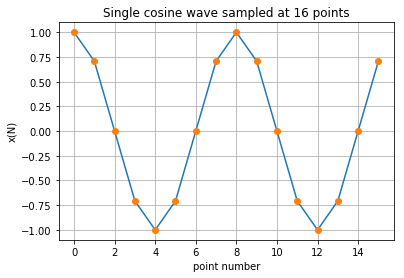

In [ ]:
# Examine a small number of points to see what happens more easily
N=16 # the fft algorithm is fastest for N a power of 2
tau = 10.0 # time length
t = np.linspace(0, tau, N, endpoint=False) # creates N points to cover tau seconds
# Choose endpoint False so that signal would fit exactly periodically within tau
print(t)
#
f = 0.2 # frequency in Hz
x = np.cos(2*np.pi*f*t) # create x array, amplitude 1.0
plt.plot(x)
plt.plot(x, 'o') # show as points and line
# Note how the plot is exactly periodic

plt.title('Single cosine wave sampled at {} points'.format(N))
plt.xlabel('point number')
plt.ylabel('x(N)')
plt.grid()

This sets up a cosine wave of just 16 points, so it looks a bit rough when plotted out, but it helps us to see better what happens when we look at the FFT. Use this code snippet to do the FFT:

[ 1.24474906e-17+0.00000000e+00j -8.73114191e-17+5.19299245e-17j
  5.00000000e-01-1.72254642e-16j  1.69824100e-17-7.40843115e-17j
  1.53080850e-17-2.77555756e-17j  2.63153929e-17-7.40843115e-17j
  5.55111512e-17-4.97899625e-17j  4.40136163e-17+5.19299245e-17j
 -4.30636606e-17+0.00000000e+00j  4.40136163e-17-5.19299245e-17j
  5.55111512e-17+4.97899625e-17j  2.63153929e-17+7.40843115e-17j
  1.53080850e-17+2.77555756e-17j  1.69824100e-17+7.40843115e-17j
  5.00000000e-01+1.72254642e-16j -8.73114191e-17-5.19299245e-17j]


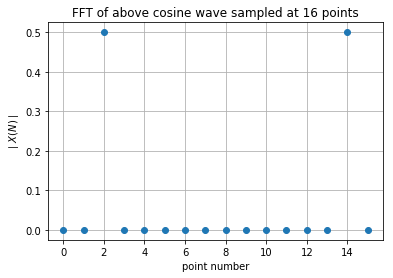

In [ ]:
X = fft(x)/N # fft and normalise
plt.plot(np.abs(X),'o')
plt.title('FFT of above cosine wave sampled at '+str(N)+' points')
plt.xlabel('point number')
plt.ylabel('$\mid X(N)\mid$')
plt.grid()
print(X)

Two things to notice:

 1. Point 0 is the zero frequency component, points 1 to 8 are the positive frequency components, points 9 to 15 are the negative frequency components. To put the latter in the ‘correct’ position we can reorder them, so that point 15 appears effectively in the -1 position, point 14 in the -2 position, and so on (since the FT is periodic with period $F_s$, there isn’t really a ‘correct’ interval any more. The algorithm returns the interval $0$ to $F_s$, but you might prefer $-F_s/2$ to $F_s/2$. You will meet exactly this idea in describing periodic crystal structures, where the FT is actually the reciprocal lattice).

 But since the negative frequency components just repeat the positive ones (as the array $x$ is real) we can just ignore them.


 2. Printing $X$ shows that it has real and imaginary parts, but that the imaginary part is zero within numerical error. This is because we picked a cosine wave as the test data.

The _wrapper_ function to the fft below is handy as it returns not just the Fourier amplitudes but also the corresponding frequencies. (There are actually other ways to do it using numpy directly, but it helps to show these details.)

In [ ]:
def Spectrum1(x, Fs):
    '''
    One-sided amplitude spectrum of x(t).
    '''
    N = len(x) # length of the signal
    frq = (float(Fs)/N)*np.arange(0, N/2+1) # one-sided frequency range
    X = fft(x)/N # fft computing and normalization
    X = X[0:N//2+1] # take just positive values
    # (in python3, // ensures integer division)

    # frq is array of actual frequencies
    # X is complex array of amplitudes
    return frq , X

The division by $N$ normalisation is there because the `fft` is implemented by numpy with a different pre-factor, equation (11); putting it in gives agreement with the ordinary Fourier transform amplitudes defined earlier. (There is no uniform convention on defining the prefactors.) Later, we’ll see that we have to multiply by $N$ again before doing the inverse discrete Fourier transform `ifft`.

# Exercises

Mark weighting is in brackets. **Save your work to GitHub after having run all cells with `Runtime` -> `Restart and run all`. And do not change the notebook's filename.** Do add comments to your code, you'll lose points if your code is hard to understand. Graphs without labels (or units when appropriate) are not worth any point.

Read section Implementation above and do the following exercises.

## Exercise 0

See LearningCentral for an example video of a simple Fourier analysis.

## Exercise 1
[2] Plot the original signal $x$ against time instead of point number. (Use N=64 points.)

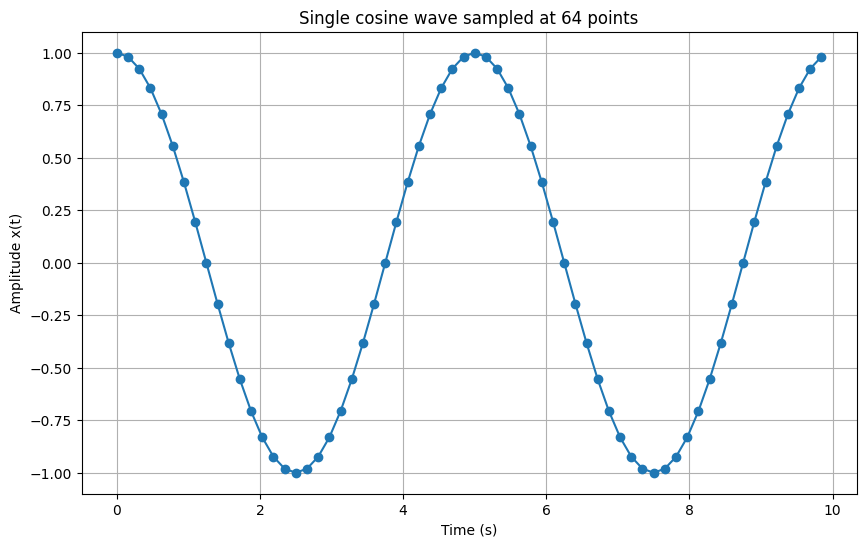

In [2]:
N = 64 # Use N=64 points as requested
tau = 10.0 # time length (from previous example)
t = np.linspace(0, tau, N, endpoint=False) # creates N points to cover tau seconds

f = 0.2 # frequency in Hz (from previous example)
x = np.cos(2*np.pi*f*t) # create x array, amplitude 1.0

plt.figure(figsize=(10, 6))
plt.plot(t, x, '-o') # Plot x against time t

plt.title('Single cosine wave sampled at {} points'.format(N))
plt.xlabel('Time (s)') # Label x-axis as Time
plt.ylabel('Amplitude x(t)') # Label y-axis as Amplitude
plt.grid(True)
plt.show()


## Exercise 2
[2] Plot just the positive frequencies of the FFT using the `fft` routine of `numpy`. This is a plot versus point number.

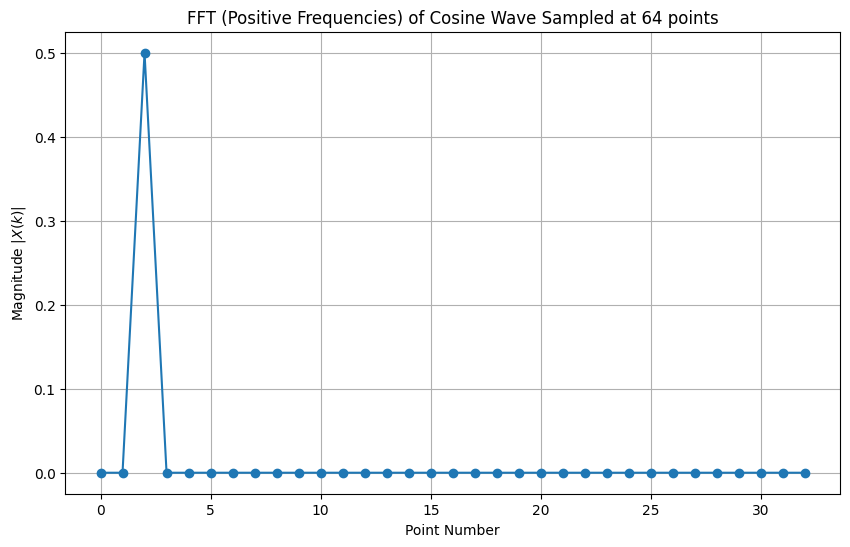

FFT (positive frequencies only): 
[-1.51027238e-17+0.00000000e+00j -6.57539646e-17+2.73952480e-17j
  5.00000000e-01-1.71433198e-16j  3.15218794e-17-1.52091252e-17j
 -2.73655488e-18-5.74860405e-19j  3.39366570e-17-3.19107167e-17j
 -3.46944695e-18-5.50859672e-18j  2.28336168e-17+2.02708552e-17j
  8.87114816e-19+1.24468911e-18j -1.50778956e-17-1.32040255e-18j
  4.38400669e-17+2.12443910e-17j -5.08806268e-18+1.84715055e-17j
  1.68000973e-18+1.18946890e-17j  2.10462876e-17-1.29552401e-17j
 -1.38777878e-17+4.89974413e-18j  9.41745543e-18+1.07408136e-17j
  1.00507666e-17+2.60208521e-18j -2.11843120e-17+3.16548162e-17j
 -2.42861287e-17-2.22469789e-17j -2.21808446e-17-4.41940088e-17j
 -3.83904511e-18-1.67027156e-17j  2.63797015e-18-3.57970783e-17j
  1.00613962e-16-5.50859672e-18j  1.34089024e-17+5.21307292e-17j
 -2.24189451e-17+2.20613708e-17j  1.37828910e-17+1.27259608e-17j
 -5.61786317e-17+4.00287177e-17j -1.41586924e-18-1.58502913e-17j
  2.02036752e-17-1.41668940e-18j -1.71602147e-17+2.38811

In [3]:
# Exercise 2
# Plot just the positive frequencies of the FFT using the fft routine of numpy.
# This is a plot versus point number.

X = fft(x)/N # fft and normalise

# As per the notebook's explanation:
# Point 0 is the zero frequency component, points 1 to N/2 are the positive frequency components.
# We can ignore the negative frequency components (N/2+1 to N-1) for real signals.
positive_frequencies_X = X[0:N//2+1]

plt.figure(figsize=(10, 6))
plt.plot(np.abs(positive_frequencies_X), 'o-')
plt.title('FFT (Positive Frequencies) of Cosine Wave Sampled at {} points'.format(N))
plt.xlabel('Point Number')
plt.ylabel('Magnitude $|X(k)|$')
plt.grid(True)
plt.show()

print("FFT (positive frequencies only): ")
print(positive_frequencies_X)

## Exercise 3

[2] For this question **and all the following**, use the `Spectrum1` function. Calculate and plot the FFT of $x$ versus frequency. (**In the rest of the exercises just plot against frequency.**) Why is the signal amplitude you find equal to 0.5 instead of 1?

 Recall: The sampling rate is $F_s = 1/\Delta t = N/\tau$. Read the section Summary above!



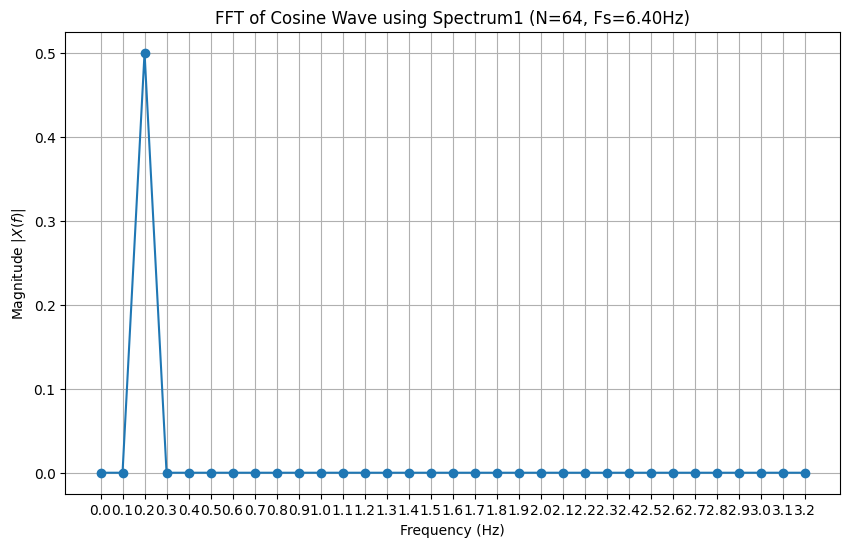

Frequencies (Hz):  [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2]
FFT Amplitudes (absolute values):  [1.51027238e-17 7.12326012e-17 5.00000000e-01 3.49992339e-17
 2.79628273e-18 4.65831571e-17 6.51012289e-18 3.05332872e-17
 1.52847103e-18 1.51356004e-17 4.87162767e-17 1.91594597e-17
 1.20127457e-17 2.47140541e-17 1.47173533e-17 1.42847312e-17
 1.03821364e-17 3.80894009e-17 3.29354538e-17 4.94479553e-17
 1.71382314e-17 3.58941458e-17 1.00764646e-16 5.38276100e-17
 3.14533493e-17 1.87594819e-17 6.89806995e-17 1.59134038e-17
 2.02532837e-17 2.94071528e-17 1.11548337e-17 1.27074455e-17
 7.44868135e-18]


In [6]:
def Spectrum1(x, Fs):
    '''
    One-sided amplitude spectrum of x(t).
    '''
    N = len(x) # length of the signal
    frq = (float(Fs)/N)*np.arange(0, N/2+1) # one-sided frequency range
    X = fft(x)/N # fft computing and normalization
    X = X[0:N//2+1] # take just positive values
    # (in python3, // ensures integer division)

    # frq is array of actual frequencies
    # X is complex array of amplitudes
    return frq , X

# Exercise 3
# Calculate and plot the FFT of x versus frequency using Spectrum1.
# Explain why the signal amplitude is 0.5 instead of 1.

# Recall: The sampling rate is Fs = 1/Delta t = N/tau.
Fs = N / tau # Calculate the sampling rate

frq, X_spectrum = Spectrum1(x, Fs)

plt.figure(figsize=(10, 6))
plt.plot(frq, np.abs(X_spectrum), 'o-')
plt.title('FFT of Cosine Wave using Spectrum1 (N={}, Fs={:.2f}Hz)'.format(N, Fs))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude $|X(f)|$')
plt.grid(True)
plt.xticks(np.arange(0, frq[-1] + 0.1, 0.1))
plt.show()

print("Frequencies (Hz): ", frq)
print("FFT Amplitudes (absolute values): ", np.abs(X_spectrum))

# Explanation for amplitude 0.5:
# The original cosine wave is x(t) = cos(2*pi*f*t). In Euler's formula, this can be written as
# cos(theta) = (e^(i*theta) + e^(-i*theta)) / 2.
# So, cos(2*pi*f*t) = (e^(i*2*pi*f*t) + e^(-i*2*pi*f*t)) / 2.
# The Fourier transform decomposes a signal into its constituent complex exponentials.
# For a real-valued cosine wave with amplitude 1, the FFT will show two peaks (one at positive frequency f and one at negative frequency -f), each with an amplitude of 0.5.
# The `Spectrum1` function specifically returns the one-sided spectrum for positive frequencies,
# so it shows the amplitude of 0.5 at the corresponding positive frequency (0.2 Hz in this case).

## Exercise 4
[2] Show what happens if you change the frequency of the original data to 0.22 Hz instead of 0.2 Hz. _Explain what you see to the demonstrator_.
(Hint: It helps to plot both the real and imaginary parts of $X$, and to plot $\mid X \mid$.)



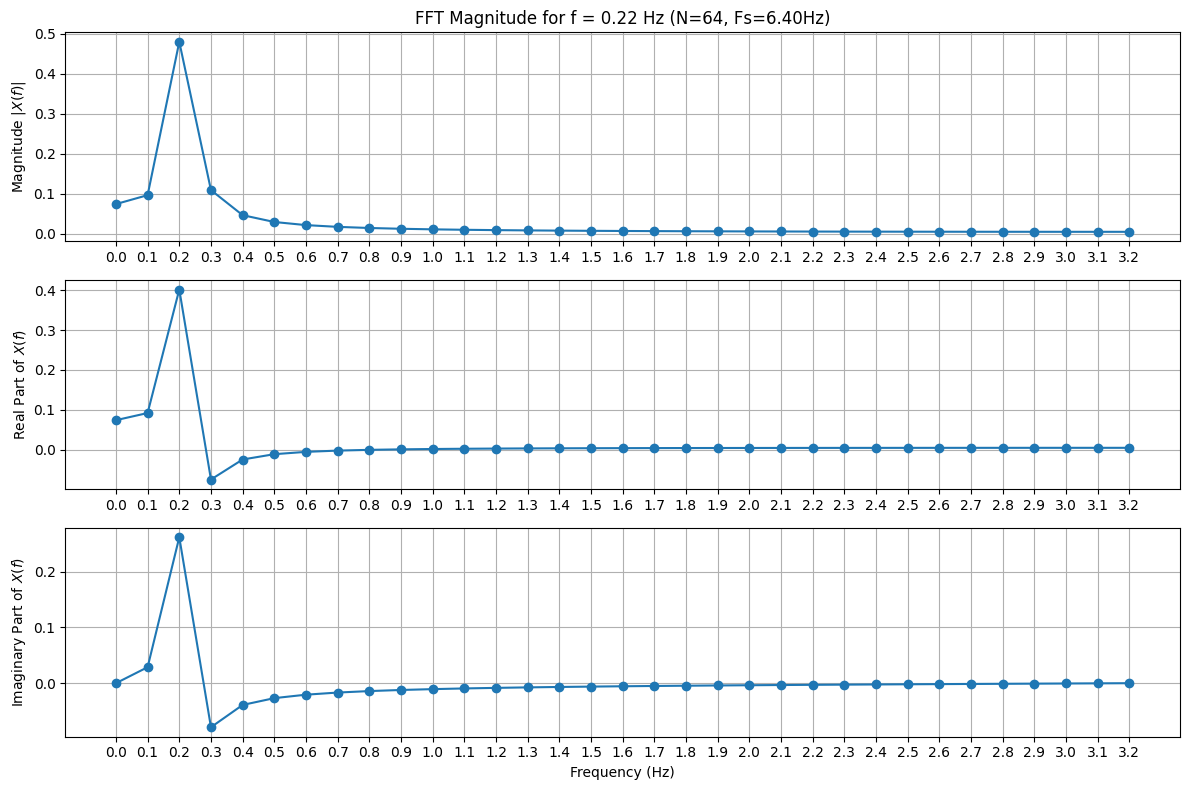

Frequencies (Hz):  [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9 3.  3.1 3.2]
FFT Amplitudes (absolute values):  [0.07393306 0.09623789 0.47948585 0.10890605 0.04622166 0.02914844
 0.0213775  0.01698049 0.01416464 0.01221121 0.01077873 0.00968497
 0.00882412 0.00813056 0.0075615  0.00708782 0.00668902 0.00635028
 0.00606059 0.00581164 0.00559702 0.00541175 0.00525189 0.00511431
 0.0049965  0.00489645 0.00481254 0.00474348 0.00468825 0.00464606
 0.00461632 0.00459864 0.00459277]
FFT Real parts:  [ 0.07393306  0.09185023  0.40156316 -0.07491952 -0.0247105  -0.01139068
 -0.00556099 -0.00241668 -0.00050672  0.00074739  0.00161777  0.00224745
  0.00271796  0.00307873  0.00336121  0.00358625  0.00376808  0.00391675
  0.00403948  0.00414157  0.00422699  0.00429874  0.00435914  0.00440998
  0.00445266  0.00448828  0.0045177   0.0045416   0.00456051  0.00457484
  0.00458487  0.00459081  0.00459277]
FFT Imaginary parts: 

In [7]:
def Spectrum1(x, Fs):
    '''
    One-sided amplitude spectrum of x(t).
    '''
    N = len(x) # length of the signal
    frq = (float(Fs)/N)*np.arange(0, N/2+1) # one-sided frequency range
    X = fft(x)/N # fft computing and normalization
    X = X[0:N//2+1] # take just positive values
    # (in python3, // ensures integer division)

    # frq is array of actual frequencies
    # X is complex array of amplitudes
    return frq , X

# Exercise 4
# Change the frequency of the original data to 0.22 Hz instead of 0.2 Hz.
# Plot both the real and imaginary parts of X, and |X|.

# Original parameters (from Exercise 1/3 setup)
N = 64
tau = 10.0
t = np.linspace(0, tau, N, endpoint=False)
Fs = N / tau # Sampling rate

f_new = 0.22 # New frequency in Hz
x_new = np.cos(2*np.pi*f_new*t) # create new x array with f_new

frq_new, X_spectrum_new = Spectrum1(x_new, Fs)

plt.figure(figsize=(12, 8))

# Plot Magnitude |X|
plt.subplot(3, 1, 1)
plt.plot(frq_new, np.abs(X_spectrum_new), 'o-')
plt.title('FFT Magnitude for f = {} Hz (N={}, Fs={:.2f}Hz)'.format(f_new, N, Fs))
plt.ylabel('Magnitude $|X(f)|$')
plt.grid(True)
plt.xticks(np.arange(0, frq_new[-1] + 0.1, 0.1))

# Plot Real part of X
plt.subplot(3, 1, 2)
plt.plot(frq_new, np.real(X_spectrum_new), 'o-')
plt.ylabel('Real Part of $X(f)$')
plt.grid(True)
plt.xticks(np.arange(0, frq_new[-1] + 0.1, 0.1))

# Plot Imaginary part of X
plt.subplot(3, 1, 3)
plt.plot(frq_new, np.imag(X_spectrum_new), 'o-')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Imaginary Part of $X(f)$')
plt.grid(True)
plt.xticks(np.arange(0, frq_new[-1] + 0.1, 0.1))

plt.tight_layout()
plt.show()

print("Frequencies (Hz): ", frq_new)
print("FFT Amplitudes (absolute values): ", np.abs(X_spectrum_new))
print("FFT Real parts: ", np.real(X_spectrum_new))
print("FFT Imaginary parts: ", np.imag(X_spectrum_new))


# Explanation for the demonstrator:
# When the frequency is changed to 0.22 Hz:
# 1. Spreading of Energy (Spectral Leakage): Unlike the 0.2 Hz case, where the peak was very sharp and located precisely at 0.2 Hz,
#    the 0.22 Hz signal shows its energy spread across multiple frequency bins.
#    This happens because 0.22 Hz is not an exact multiple of the fundamental frequency resolution (Delta f = Fs/N = (N/tau)/N = 1/tau = 1/10 = 0.1 Hz).
#    The closest frequency bins are 0.2 Hz and 0.3 Hz, and the energy 'leaks' into these surrounding bins.
#    This phenomenon is known as spectral leakage and is characteristic of analyzing signals whose frequencies are not integer multiples of the fundamental frequency resolution (1/tau).
# 2. Non-zero Imaginary Part: For a pure cosine wave (which is an even function), the FFT should ideally have only a real component.
#    However, due to spectral leakage, the energy spread also introduces a significant imaginary part in the FFT.
#    This indicates that the discrete Fourier transform of a non-periodically sampled segment of the cosine wave is no longer purely real or purely even in its frequency components.
#    The phase information (represented by the imaginary part) becomes important when the signal's period does not perfectly align with the sampling window.
# 3. Peak Amplitude: The peak magnitude is no longer exactly 0.5. Due to the spreading of energy, the maximum amplitude in a single bin is reduced compared to the ideal case where the signal frequency perfectly matches a bin.

## Exercise 5

[4] (a) Investigate what happens as you sample the original data with more points,  and (b) what happens as you increase the lenght $\tau$ of the original data (for both 0.2 and 0.22 Hz).



Part (a): Investigating the effect of changing N (number of sample points) while keeping tau (time length) constant.
Frequency: 0.2 Hz


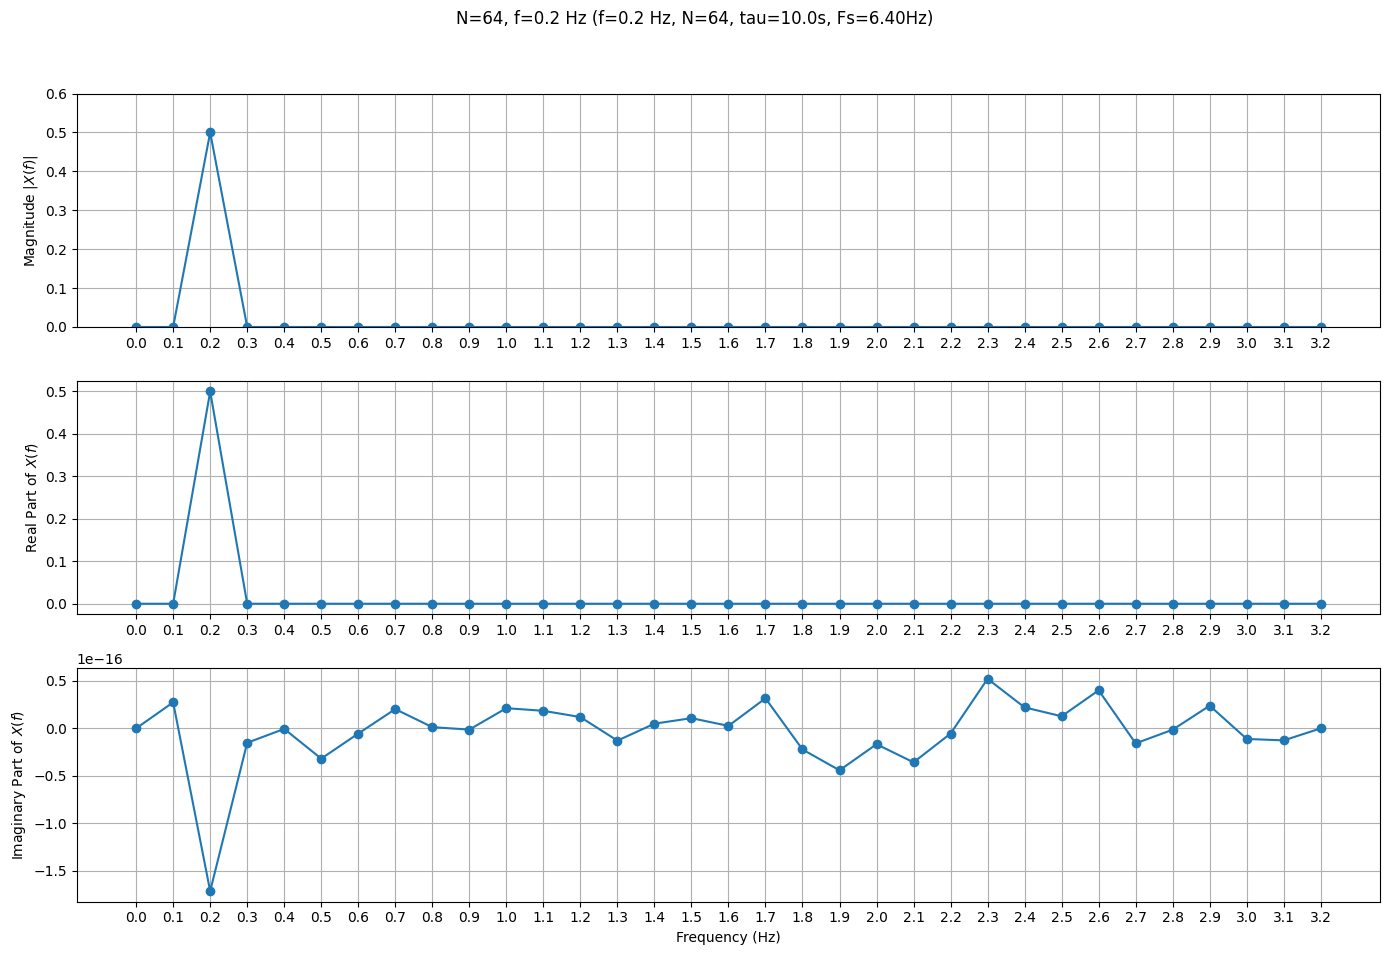

--- N=64, f=0.2 Hz (f=0.2 Hz) ---
N: 64, tau: 10.0s, Fs: 6.40Hz, Delta f: 0.100Hz
Peak Frequency Bin: 0.200 Hz, Magnitude: 0.500




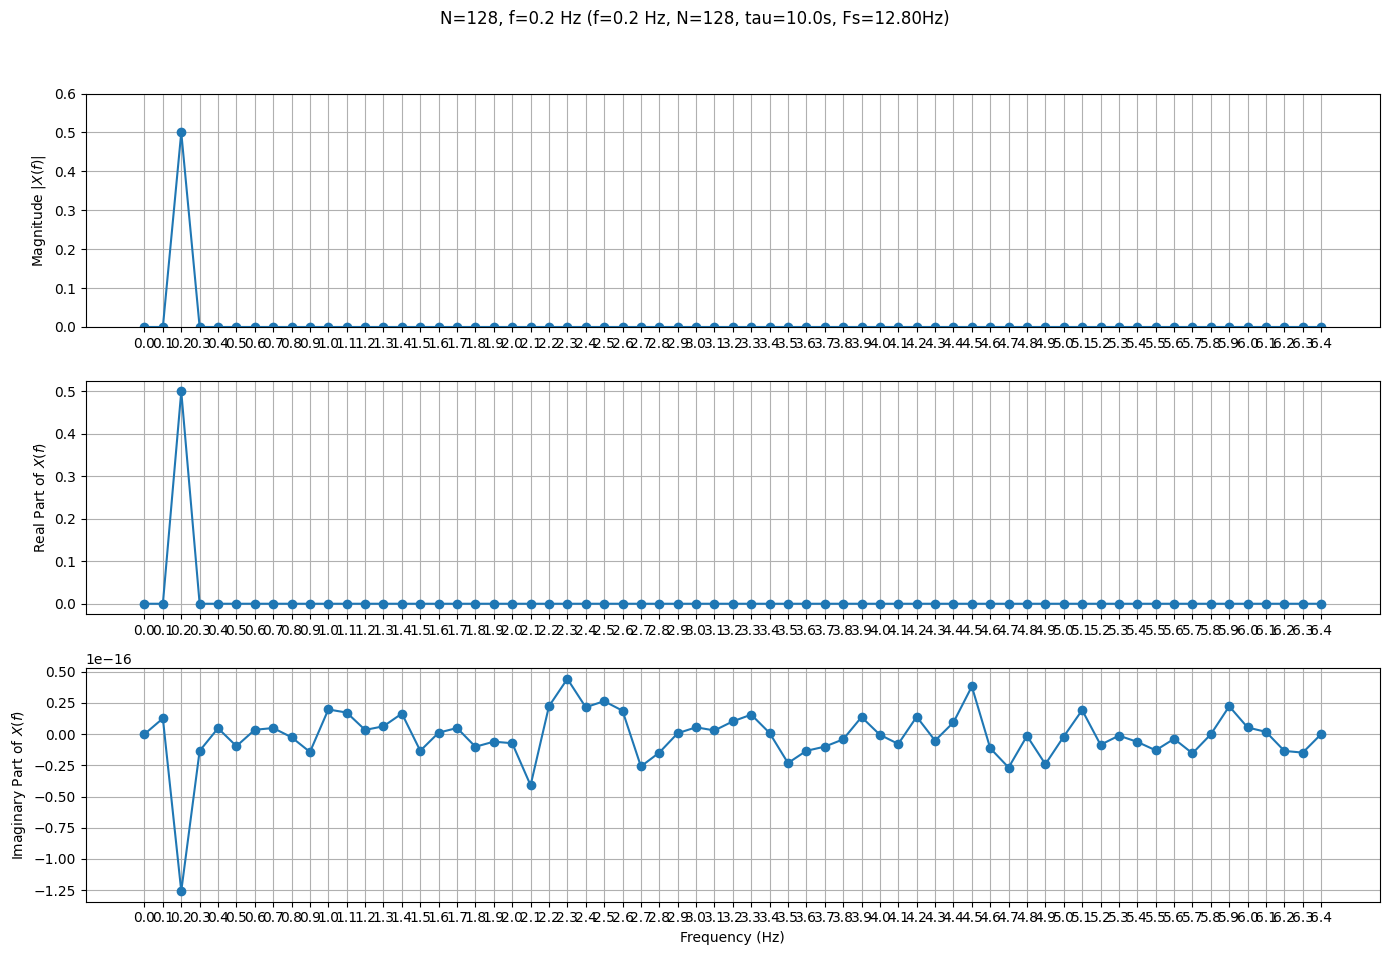

--- N=128, f=0.2 Hz (f=0.2 Hz) ---
N: 128, tau: 10.0s, Fs: 12.80Hz, Delta f: 0.100Hz
Peak Frequency Bin: 0.200 Hz, Magnitude: 0.500




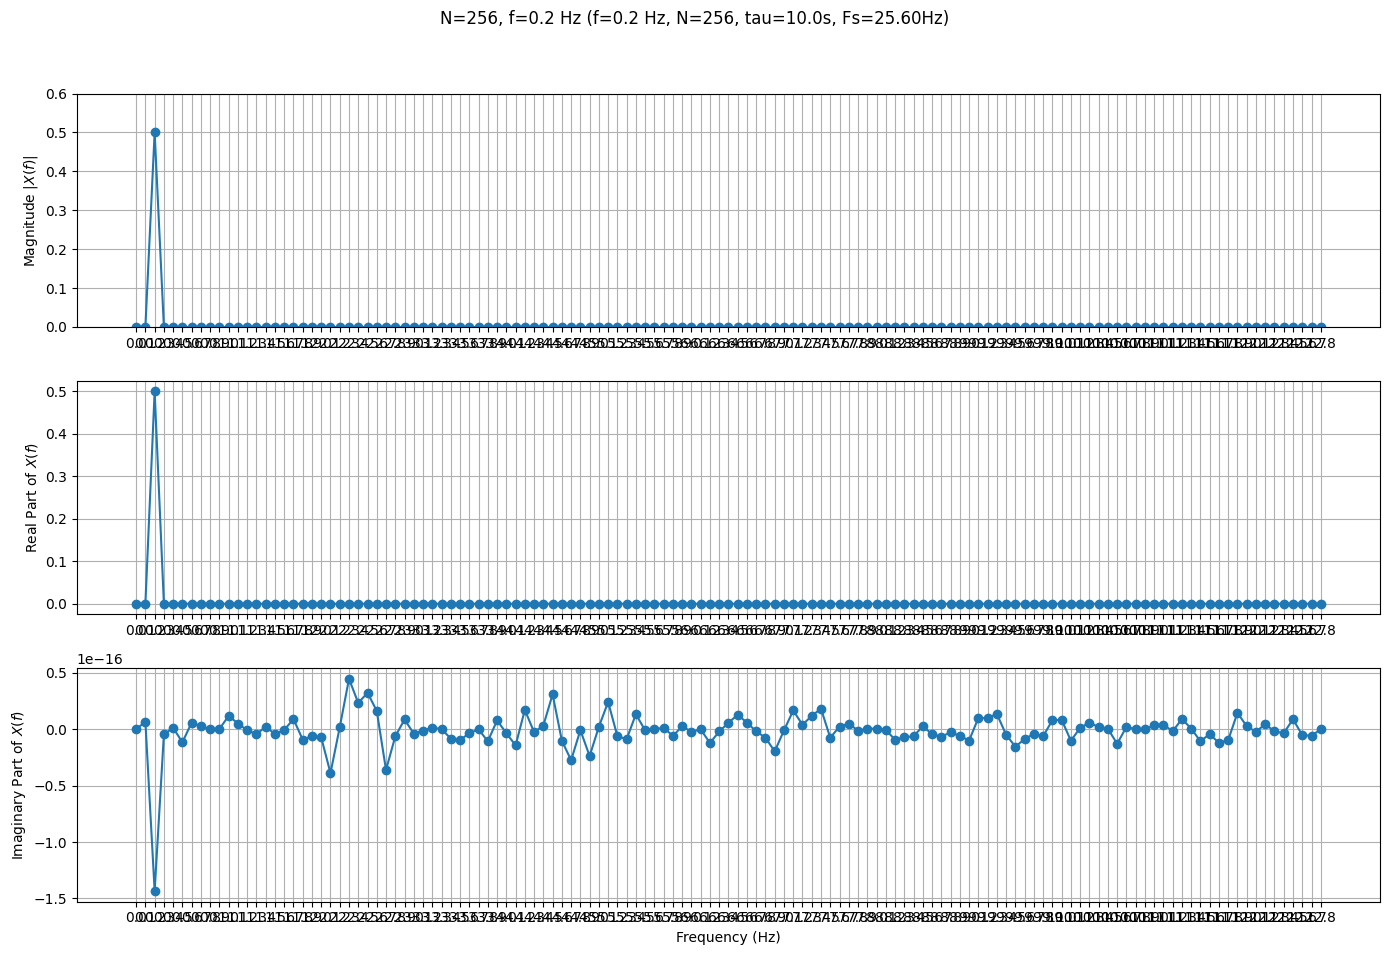

--- N=256, f=0.2 Hz (f=0.2 Hz) ---
N: 256, tau: 10.0s, Fs: 25.60Hz, Delta f: 0.100Hz
Peak Frequency Bin: 0.200 Hz, Magnitude: 0.500


Frequency: 0.22 Hz


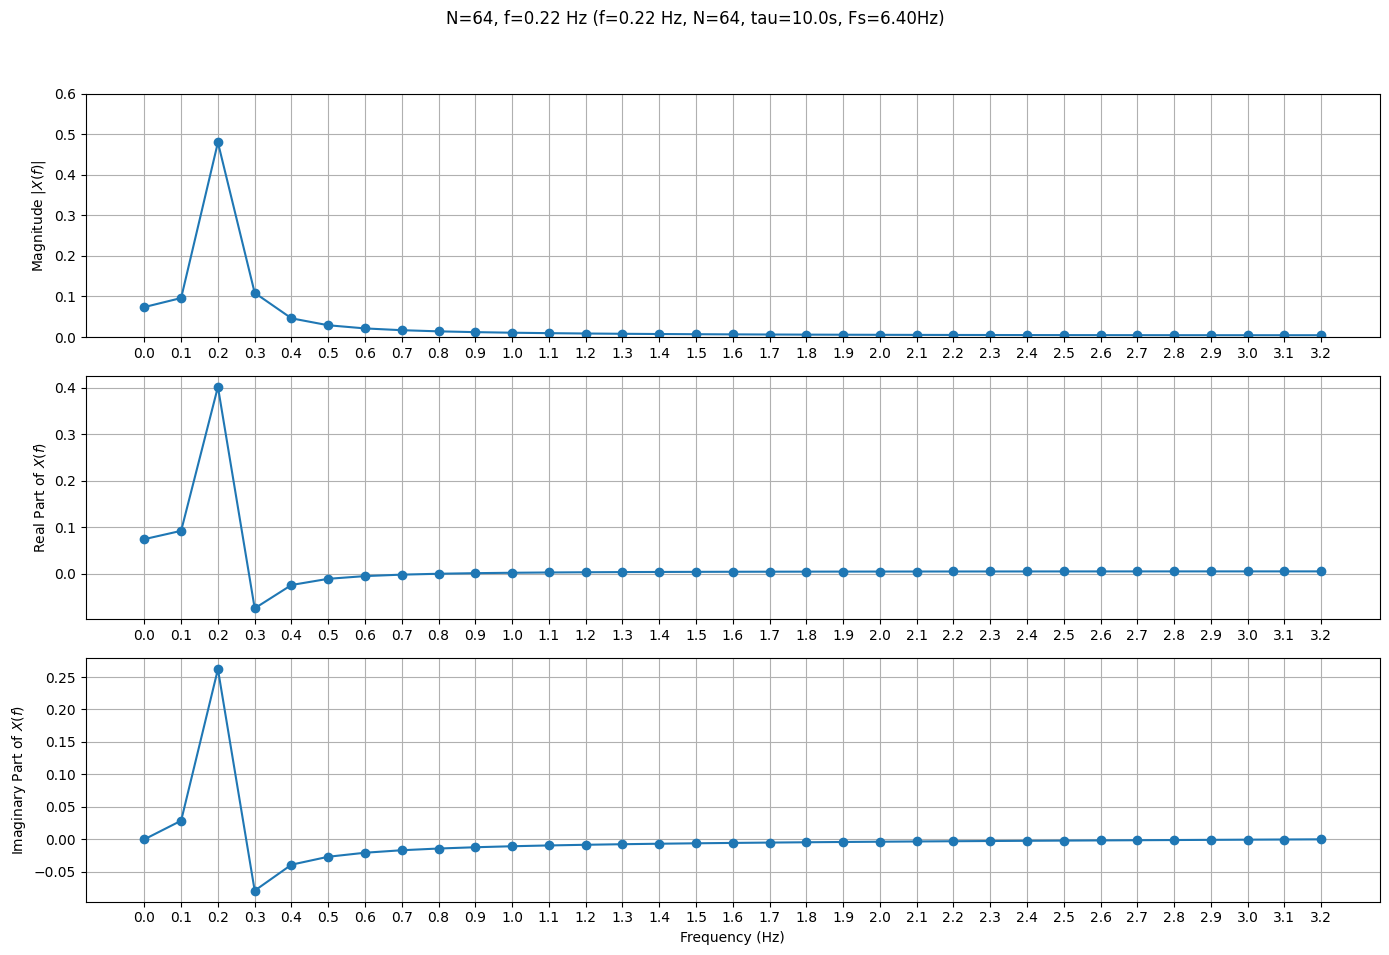

--- N=64, f=0.22 Hz (f=0.22 Hz) ---
N: 64, tau: 10.0s, Fs: 6.40Hz, Delta f: 0.100Hz
Peak Frequency Bin: 0.200 Hz, Magnitude: 0.479
Original frequency is not exactly aligned with a bin, indicating potential spectral leakage.




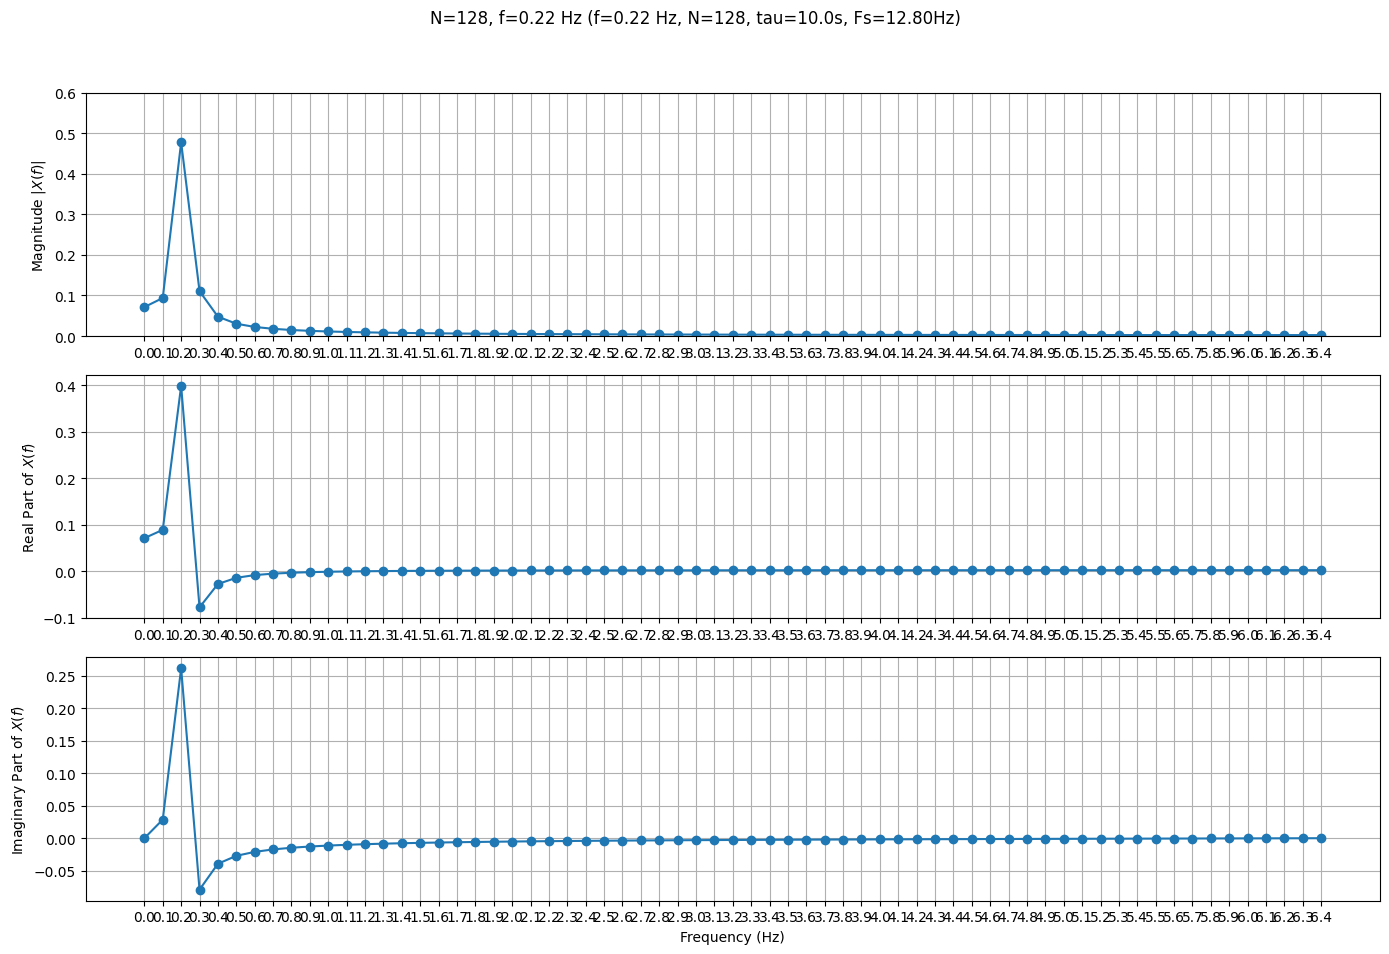

--- N=128, f=0.22 Hz (f=0.22 Hz) ---
N: 128, tau: 10.0s, Fs: 12.80Hz, Delta f: 0.100Hz
Peak Frequency Bin: 0.200 Hz, Magnitude: 0.477
Original frequency is not exactly aligned with a bin, indicating potential spectral leakage.




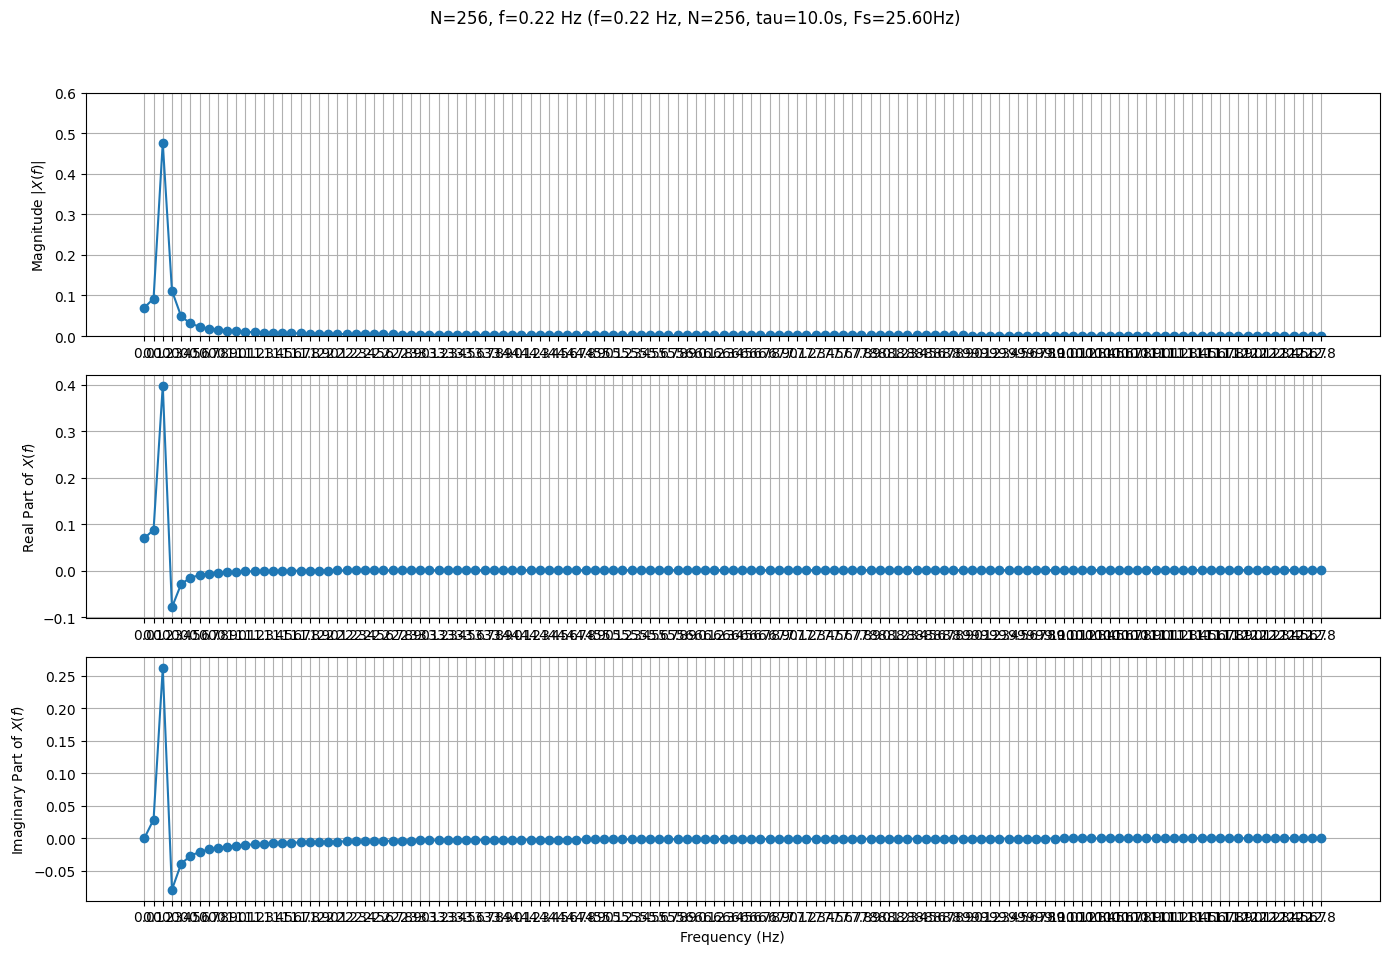

--- N=256, f=0.22 Hz (f=0.22 Hz) ---
N: 256, tau: 10.0s, Fs: 25.60Hz, Delta f: 0.100Hz
Peak Frequency Bin: 0.200 Hz, Magnitude: 0.476
Original frequency is not exactly aligned with a bin, indicating potential spectral leakage.






Part (b): Investigating the effect of increasing tau (time length) while keeping N (number of sample points) constant.
Frequency: 0.2 Hz


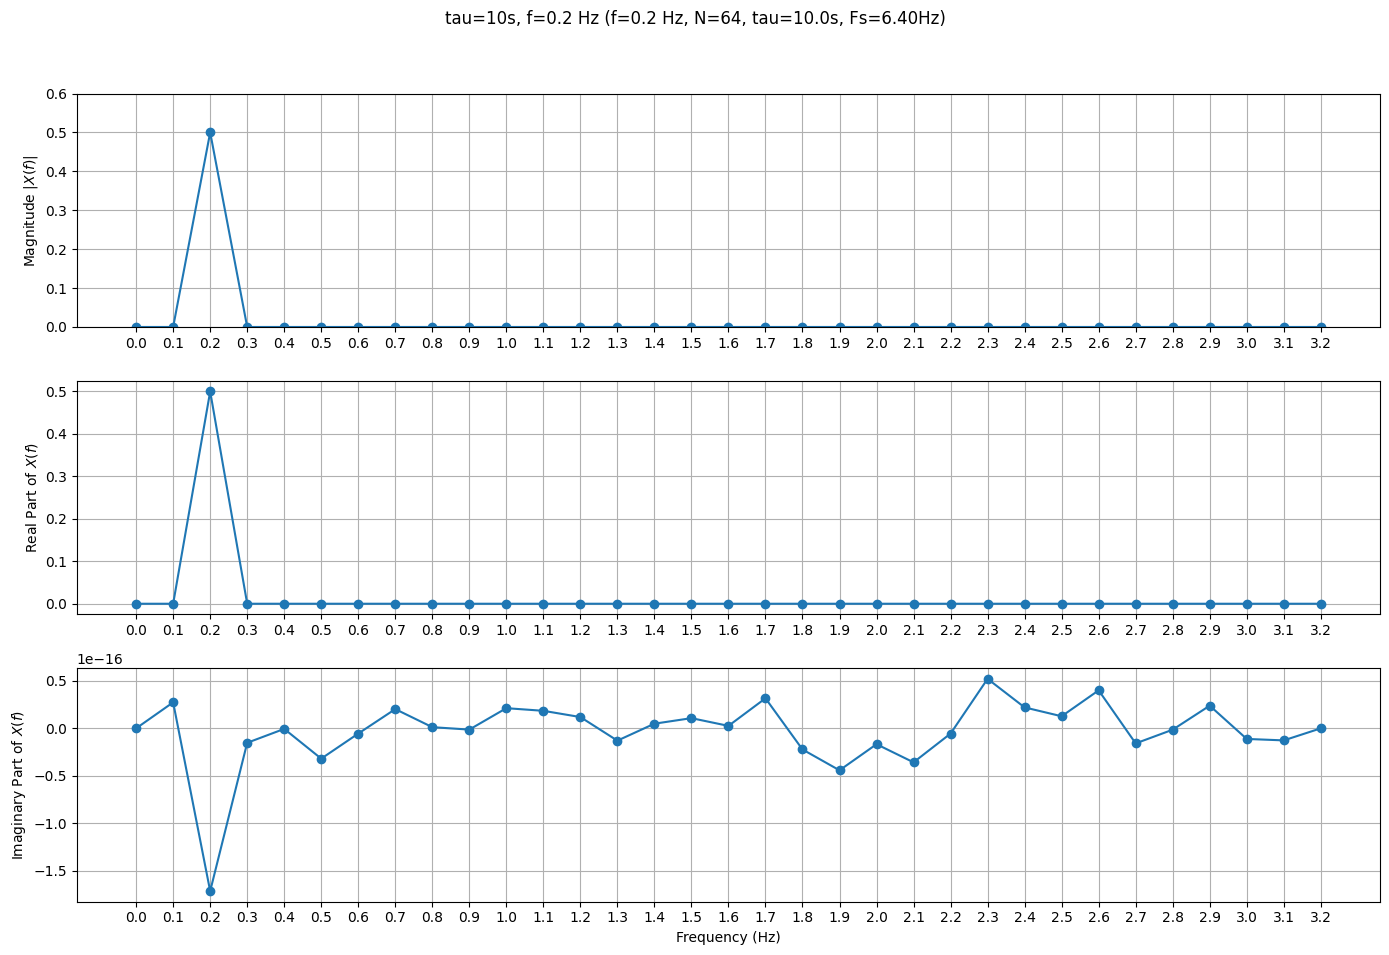

--- tau=10s, f=0.2 Hz (f=0.2 Hz) ---
N: 64, tau: 10.0s, Fs: 6.40Hz, Delta f: 0.100Hz
Peak Frequency Bin: 0.200 Hz, Magnitude: 0.500




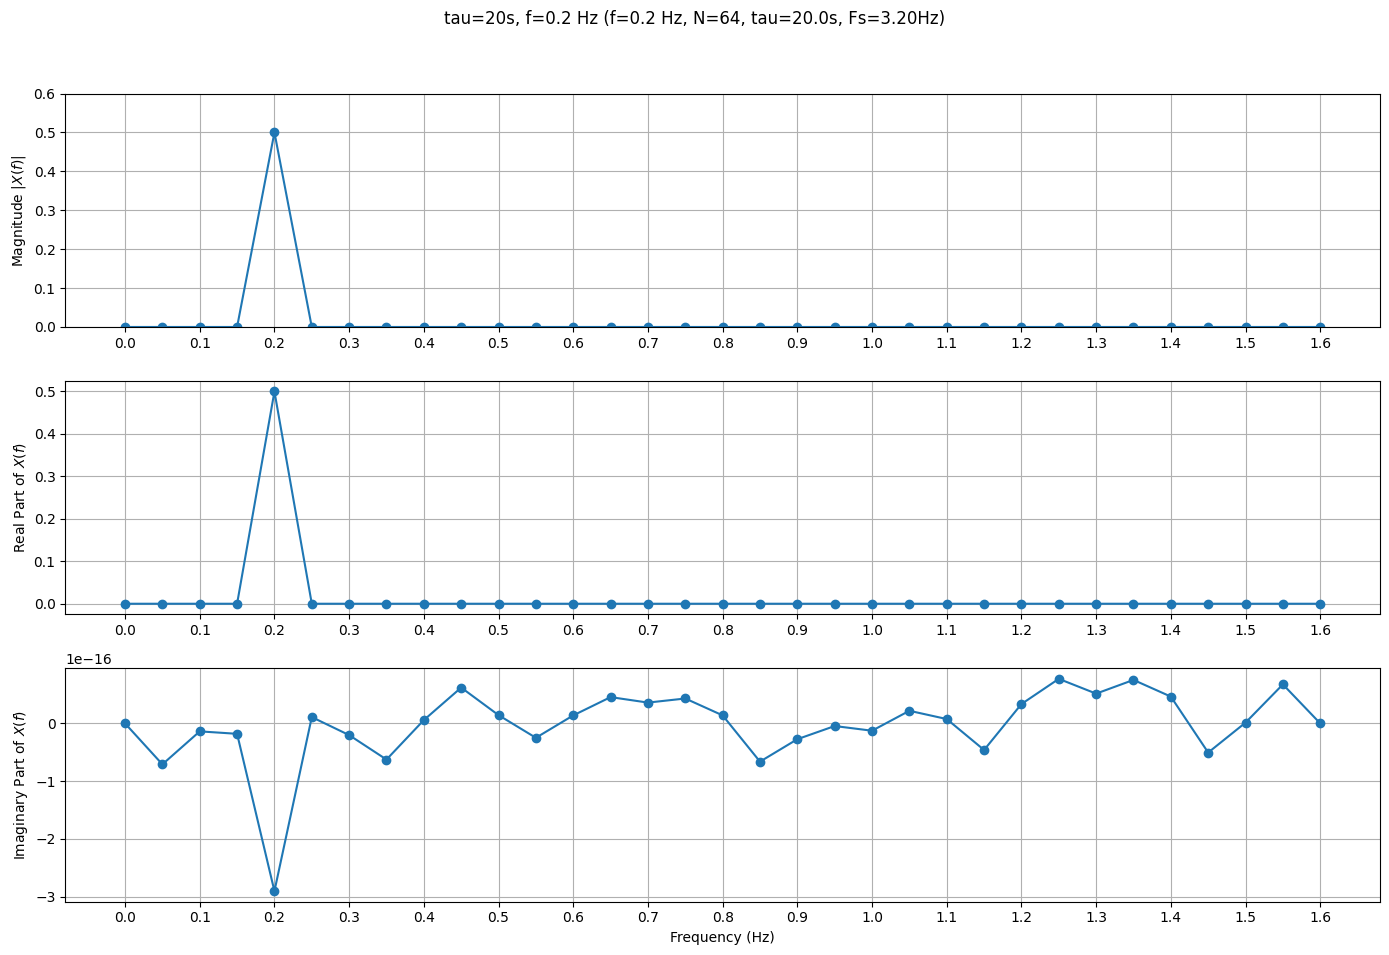

--- tau=20s, f=0.2 Hz (f=0.2 Hz) ---
N: 64, tau: 20.0s, Fs: 3.20Hz, Delta f: 0.050Hz
Peak Frequency Bin: 0.200 Hz, Magnitude: 0.500




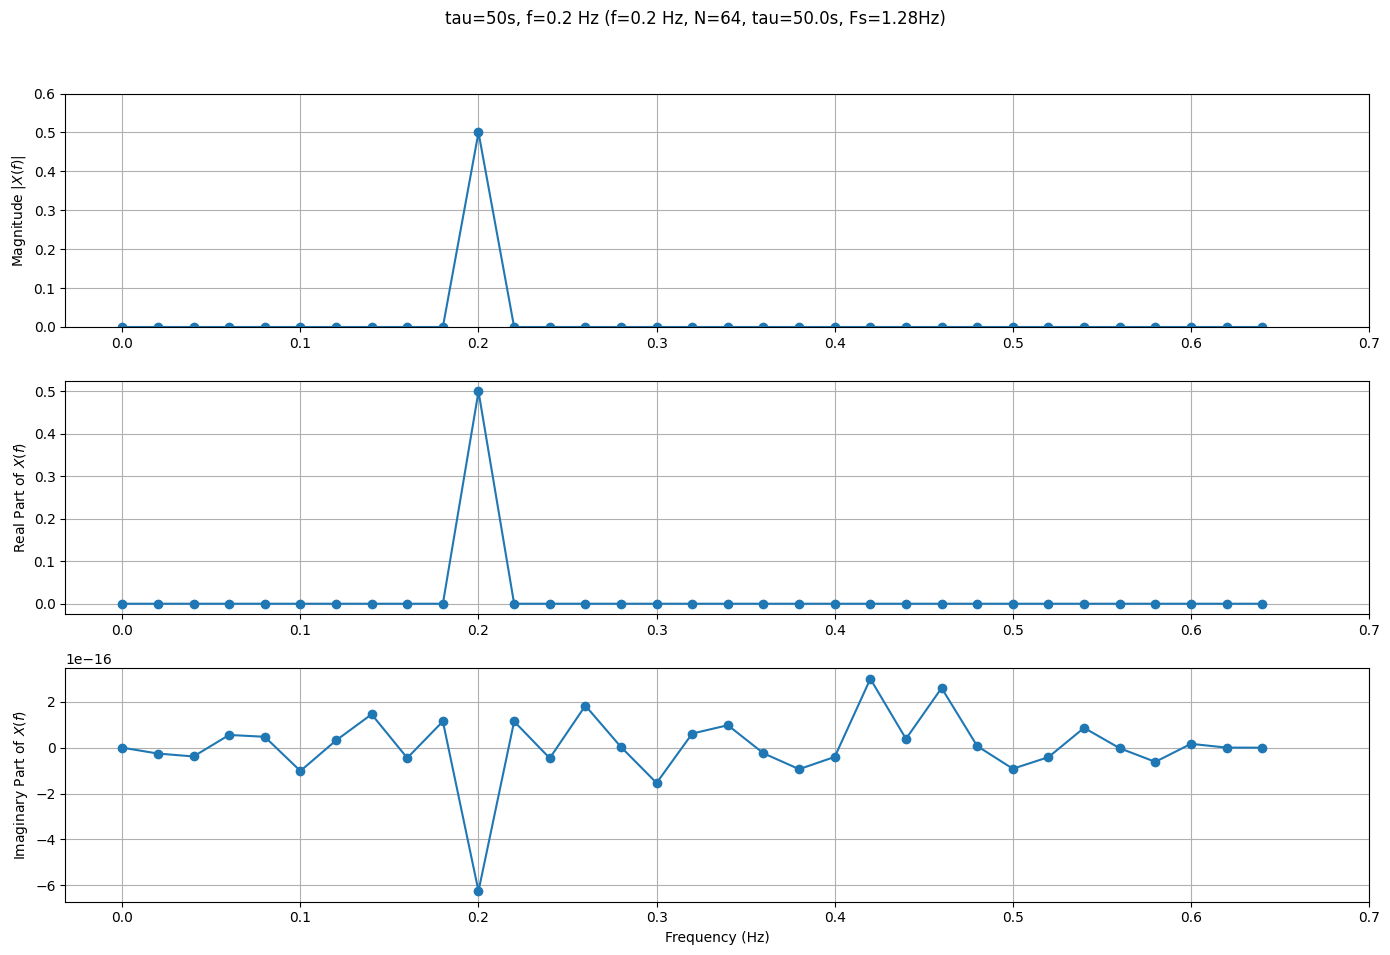

--- tau=50s, f=0.2 Hz (f=0.2 Hz) ---
N: 64, tau: 50.0s, Fs: 1.28Hz, Delta f: 0.020Hz
Peak Frequency Bin: 0.200 Hz, Magnitude: 0.500


Frequency: 0.22 Hz


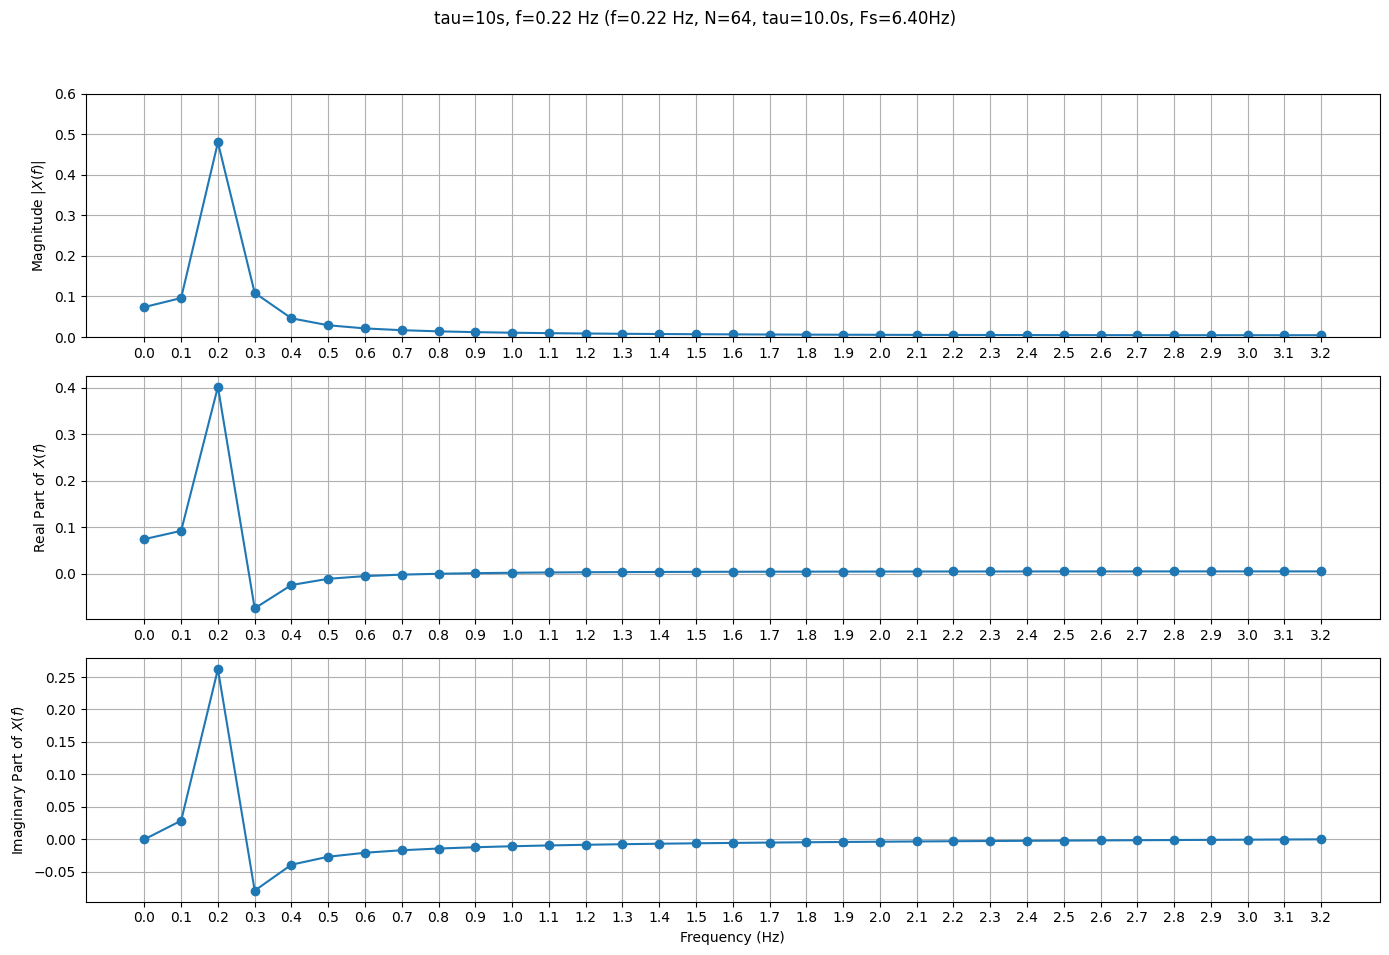

--- tau=10s, f=0.22 Hz (f=0.22 Hz) ---
N: 64, tau: 10.0s, Fs: 6.40Hz, Delta f: 0.100Hz
Peak Frequency Bin: 0.200 Hz, Magnitude: 0.479
Original frequency is not exactly aligned with a bin, indicating potential spectral leakage.




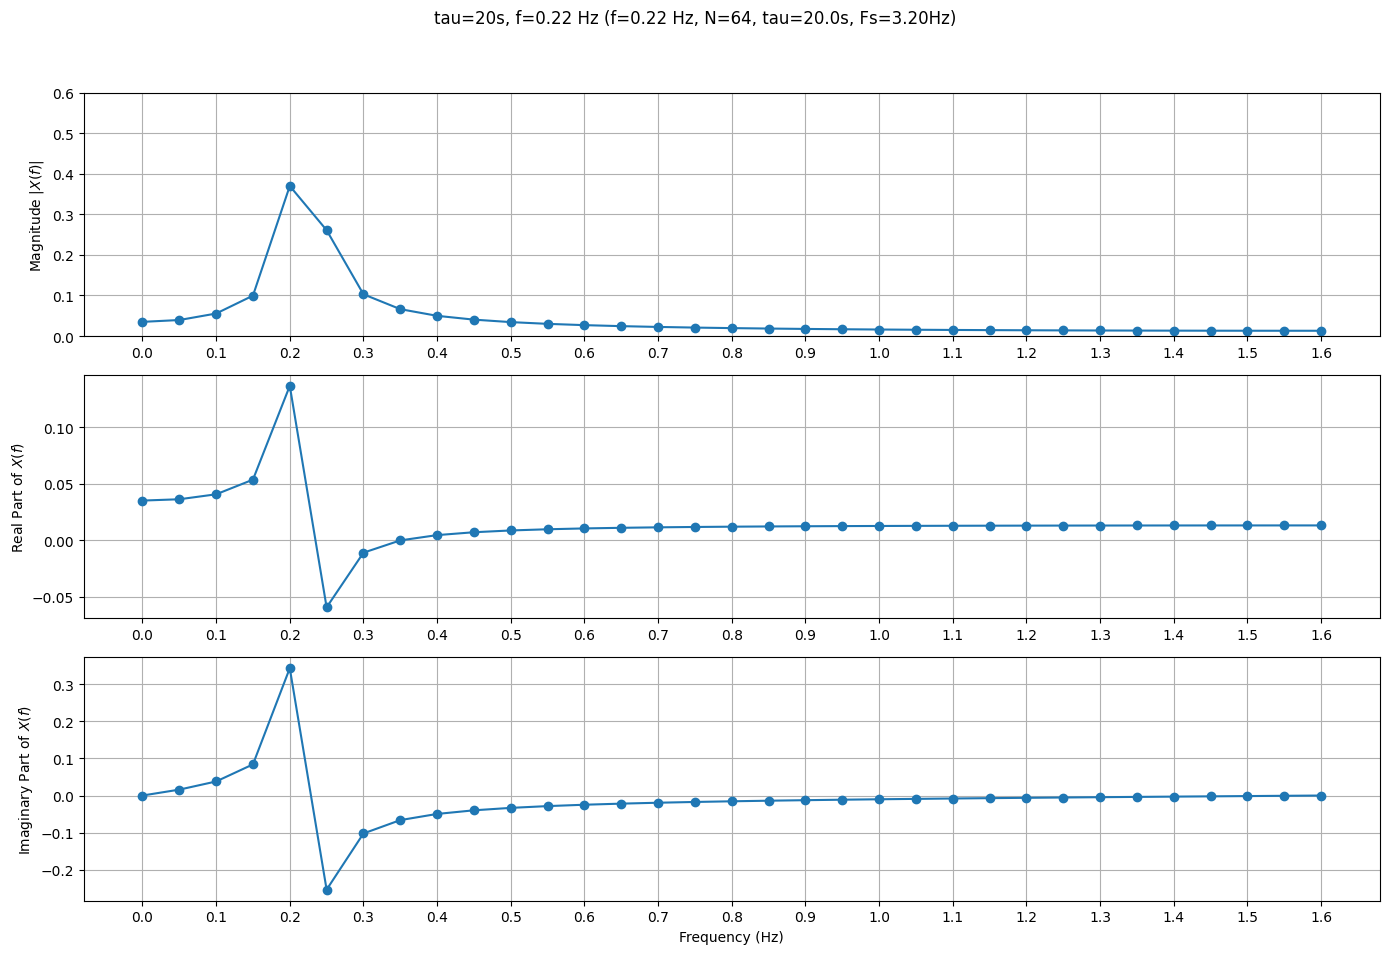

--- tau=20s, f=0.22 Hz (f=0.22 Hz) ---
N: 64, tau: 20.0s, Fs: 3.20Hz, Delta f: 0.050Hz
Peak Frequency Bin: 0.200 Hz, Magnitude: 0.370
Original frequency is not exactly aligned with a bin, indicating potential spectral leakage.




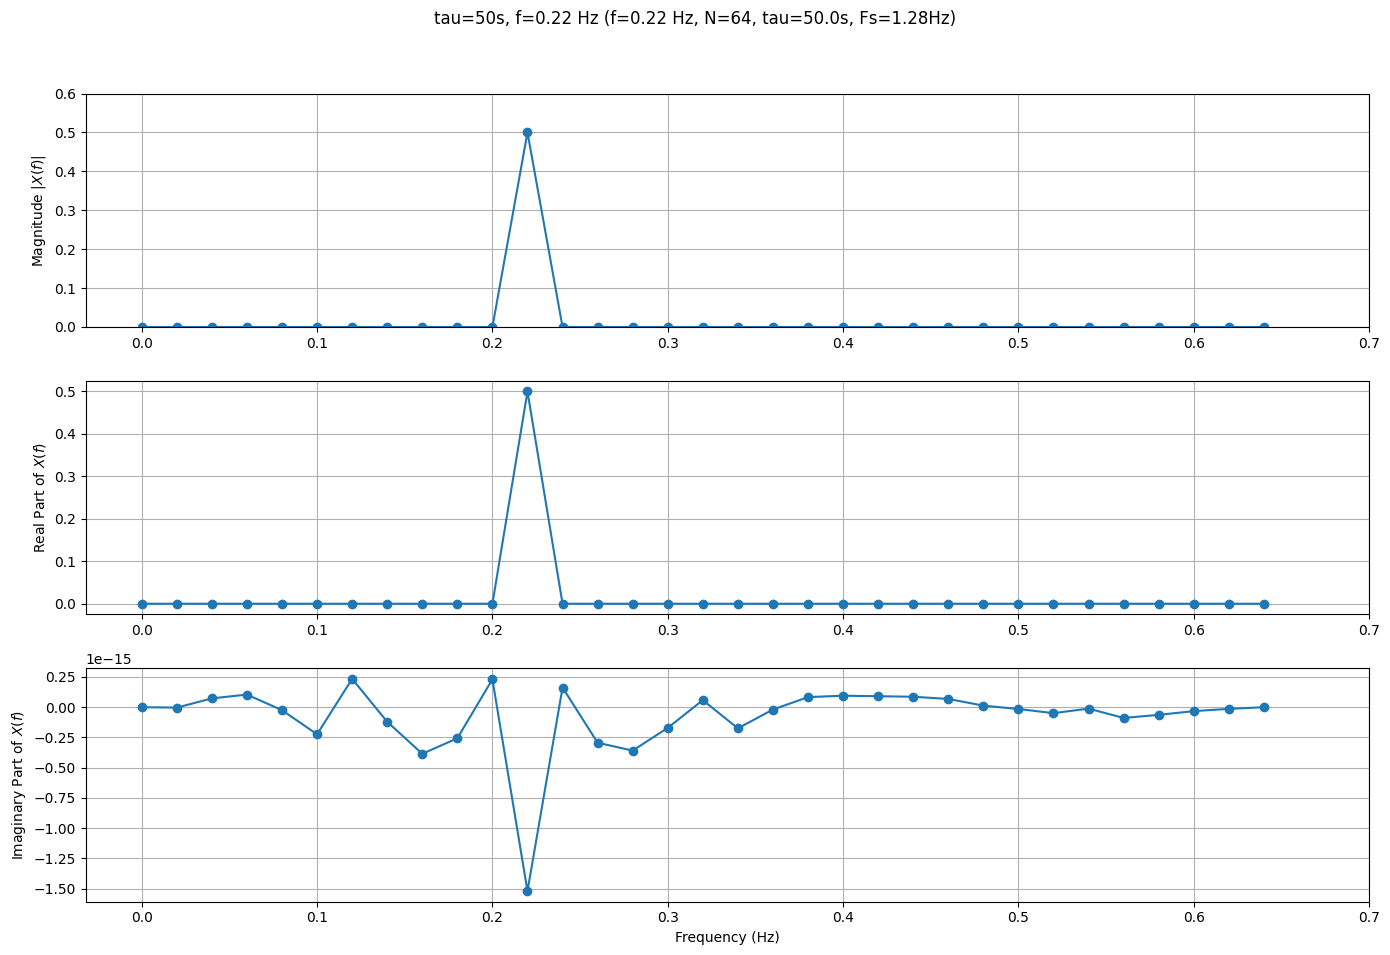

--- tau=50s, f=0.22 Hz (f=0.22 Hz) ---
N: 64, tau: 50.0s, Fs: 1.28Hz, Delta f: 0.020Hz
Peak Frequency Bin: 0.220 Hz, Magnitude: 0.500




In [8]:
def Spectrum1(x, Fs):
    '''
    One-sided amplitude spectrum of x(t).
    '''
    N = len(x) # length of the signal
    frq = (float(Fs)/N)*np.arange(0, N/2+1) # one-sided frequency range
    X = fft(x)/N # fft computing and normalization
    X = X[0:N//2+1] # take just positive values

    # frq is array of actual frequencies
    # X is complex array of amplitudes
    return frq , X

def plot_fft_scenario(N_val, tau_val, f_val, scenario_description):
    '''
    Helper function to generate signal, compute FFT, and plot results.
    '''
    t = np.linspace(0, tau_val, N_val, endpoint=False)
    Fs_val = N_val / tau_val # Sampling rate
    x_val = np.cos(2*np.pi*f_val*t)

    frq, X_spectrum = Spectrum1(x_val, Fs_val)

    plt.figure(figsize=(14, 10))
    plt.suptitle(scenario_description + f' (f={f_val} Hz, N={N_val}, tau={tau_val}s, Fs={Fs_val:.2f}Hz)')

    # Plot Magnitude |X|
    plt.subplot(3, 1, 1)
    plt.plot(frq, np.abs(X_spectrum), 'o-')
    plt.ylabel('Magnitude $|X(f)|$')
    plt.grid(True)
    plt.xticks(np.arange(0, frq[-1] + 0.1, 0.1) if frq[-1] > 0.1 else None)
    plt.ylim(0, 0.6) # Consistent y-axis for magnitude

    # Plot Real part of X
    plt.subplot(3, 1, 2)
    plt.plot(frq, np.real(X_spectrum), 'o-')
    plt.ylabel('Real Part of $X(f)$')
    plt.grid(True)
    plt.xticks(np.arange(0, frq[-1] + 0.1, 0.1) if frq[-1] > 0.1 else None)

    # Plot Imaginary part of X
    plt.subplot(3, 1, 3)
    plt.plot(frq, np.imag(X_spectrum), 'o-')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Imaginary Part of $X(f)$')
    plt.grid(True)
    plt.xticks(np.arange(0, frq[-1] + 0.1, 0.1) if frq[-1] > 0.1 else None)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Print relevant info for analysis
    print(f"--- {scenario_description} (f={f_val} Hz) ---")
    print(f"N: {N_val}, tau: {tau_val}s, Fs: {Fs_val:.2f}Hz, Delta f: {1/tau_val:.3f}Hz")
    peak_freq_idx = np.argmax(np.abs(X_spectrum))
    print(f"Peak Frequency Bin: {frq[peak_freq_idx]:.3f} Hz, Magnitude: {np.abs(X_spectrum[peak_freq_idx]):.3f}")
    if f_val not in frq:
        print("Original frequency is not exactly aligned with a bin, indicating potential spectral leakage.")
    print("\n")


# --- Exercise 5: Investigation ---

# (a) Investigate what happens as you sample the original data with more points (N)
print("Part (a): Investigating the effect of changing N (number of sample points) while keeping tau (time length) constant.")

# Scenario 1: f=0.2 Hz, vary N
tau_fixed = 10.0
print("Frequency: 0.2 Hz")
plot_fft_scenario(N_val=64, tau_val=tau_fixed, f_val=0.2, scenario_description='N=64, f=0.2 Hz')
plot_fft_scenario(N_val=128, tau_val=tau_fixed, f_val=0.2, scenario_description='N=128, f=0.2 Hz')
plot_fft_scenario(N_val=256, tau_val=tau_fixed, f_val=0.2, scenario_description='N=256, f=0.2 Hz')

# Scenario 2: f=0.22 Hz, vary N
print("Frequency: 0.22 Hz")
plot_fft_scenario(N_val=64, tau_val=tau_fixed, f_val=0.22, scenario_description='N=64, f=0.22 Hz')
plot_fft_scenario(N_val=128, tau_val=tau_fixed, f_val=0.22, scenario_description='N=128, f=0.22 Hz')
plot_fft_scenario(N_val=256, tau_val=tau_fixed, f_val=0.22, scenario_description='N=256, f=0.22 Hz')

print("\n" * 3)

# (b) Investigate what happens as you increase the length tau of the original data
print("Part (b): Investigating the effect of increasing tau (time length) while keeping N (number of sample points) constant.")

# Scenario 3: f=0.2 Hz, vary tau
N_fixed = 64 # Use a fixed N for this part
print("Frequency: 0.2 Hz")
plot_fft_scenario(N_val=N_fixed, tau_val=10.0, f_val=0.2, scenario_description='tau=10s, f=0.2 Hz')
plot_fft_scenario(N_val=N_fixed, tau_val=20.0, f_val=0.2, scenario_description='tau=20s, f=0.2 Hz')
plot_fft_scenario(N_val=N_fixed, tau_val=50.0, f_val=0.2, scenario_description='tau=50s, f=0.2 Hz')

# Scenario 4: f=0.22 Hz, vary tau
print("Frequency: 0.22 Hz")
plot_fft_scenario(N_val=N_fixed, tau_val=10.0, f_val=0.22, scenario_description='tau=10s, f=0.22 Hz')
plot_fft_scenario(N_val=N_fixed, tau_val=20.0, f_val=0.22, scenario_description='tau=20s, f=0.22 Hz')
plot_fft_scenario(N_val=N_fixed, tau_val=50.0, f_val=0.22, scenario_description='tau=50s, f=0.22 Hz')


# Explanation for demonstrator:
# Summary of Observations for Exercise 5:
# (a) Effect of increasing N (more sample points, fixed tau):
#     - Fs (sampling rate) increases proportionally with N (Fs = N/tau).
#     - Delta f (frequency resolution, 1/tau) remains constant. The spacing between frequency bins remains the same.
#     - For f=0.2 Hz (which is an exact multiple of 1/tau = 0.1 Hz), the peak remains sharp at 0.2 Hz with amplitude 0.5. Increasing N means more bins cover the same frequency range, making the spectrum look 'denser' but not changing the fundamental resolution or peak characteristics for this 'on-bin' frequency.
#     - For f=0.22 Hz (which is not an exact multiple of 1/tau = 0.1 Hz):
#         - Spectral leakage persists. The energy is still spread across multiple bins.
#         - However, as N increases, Fs increases, meaning we are sampling the signal more finely. The 'shape' of the leakage pattern might become smoother or more resolved within the existing frequency bins, but the fundamental issue of the true frequency not aligning with a bin persists, and thus the peak still appears 'blurry' compared to the 0.2 Hz case.

# (b) Effect of increasing tau (longer time length, fixed N):
#     - Fs (sampling rate) decreases (Fs = N/tau).
#     - Delta f (frequency resolution, 1/tau) decreases (becomes finer). This is the most significant effect. The frequency bins become closer together.
#     - For f=0.2 Hz:
#         - If 0.2 Hz remains an exact multiple of the new 1/tau, the peak remains sharp at 0.2 Hz with amplitude 0.5. For example, if tau=20s, 1/tau=0.05Hz, and 0.2Hz is 4*0.05Hz. The peak stays clean.
#         - The FFT can resolve the frequency more accurately because the frequency bins are narrower.
#     - For f=0.22 Hz:
#         - As tau increases, Delta f decreases, making the frequency bins narrower.
#         - This allows the FFT to resolve the actual frequency 0.22 Hz more precisely. We observe that the spectral leakage (spreading of energy) becomes less pronounced, and the peak corresponding to 0.22 Hz becomes sharper and more localized, closer to an amplitude of 0.5.
#         - If tau is increased sufficiently such that 0.22 Hz becomes an exact multiple of 1/tau (e.g., if tau was 50s, 1/tau = 0.02 Hz, and 0.22 Hz is 11*0.02 Hz), the spectral leakage would diminish significantly, and the peak would become very sharp, similar to the 0.2 Hz case.

# Conclusion for Exercise 5:
# - Increasing `N` (number of sample points) alone, while keeping `tau` fixed, increases the sampling rate `Fs` but does *not* improve frequency resolution (`Delta f`). It just samples the existing frequency bins more densely. If spectral leakage is present, it will still be there.
# - Increasing `tau` (time length) is crucial for improving *frequency resolution* (`Delta f = 1/tau`). A longer observation time allows the FFT to distinguish between closely spaced frequencies and significantly reduces spectral leakage, making the peaks sharper and more accurate in amplitude, especially for frequencies that were initially 'off-bin'.

## Exercise 6

[4] Describe what happens to the FFT if you choose non-zero phase in the cosine waves (for both 0.2 and 0.22 Hz). (Hint: Plot both the real and imaginary parts of $X$ in one graph, and $\mid X\mid$ and the argument $\arg(X)$ as a function of frequency on another graph. The function `np.angle()` will be helpful to do this.)

Investigating the effect of non-zero phase in cosine waves.


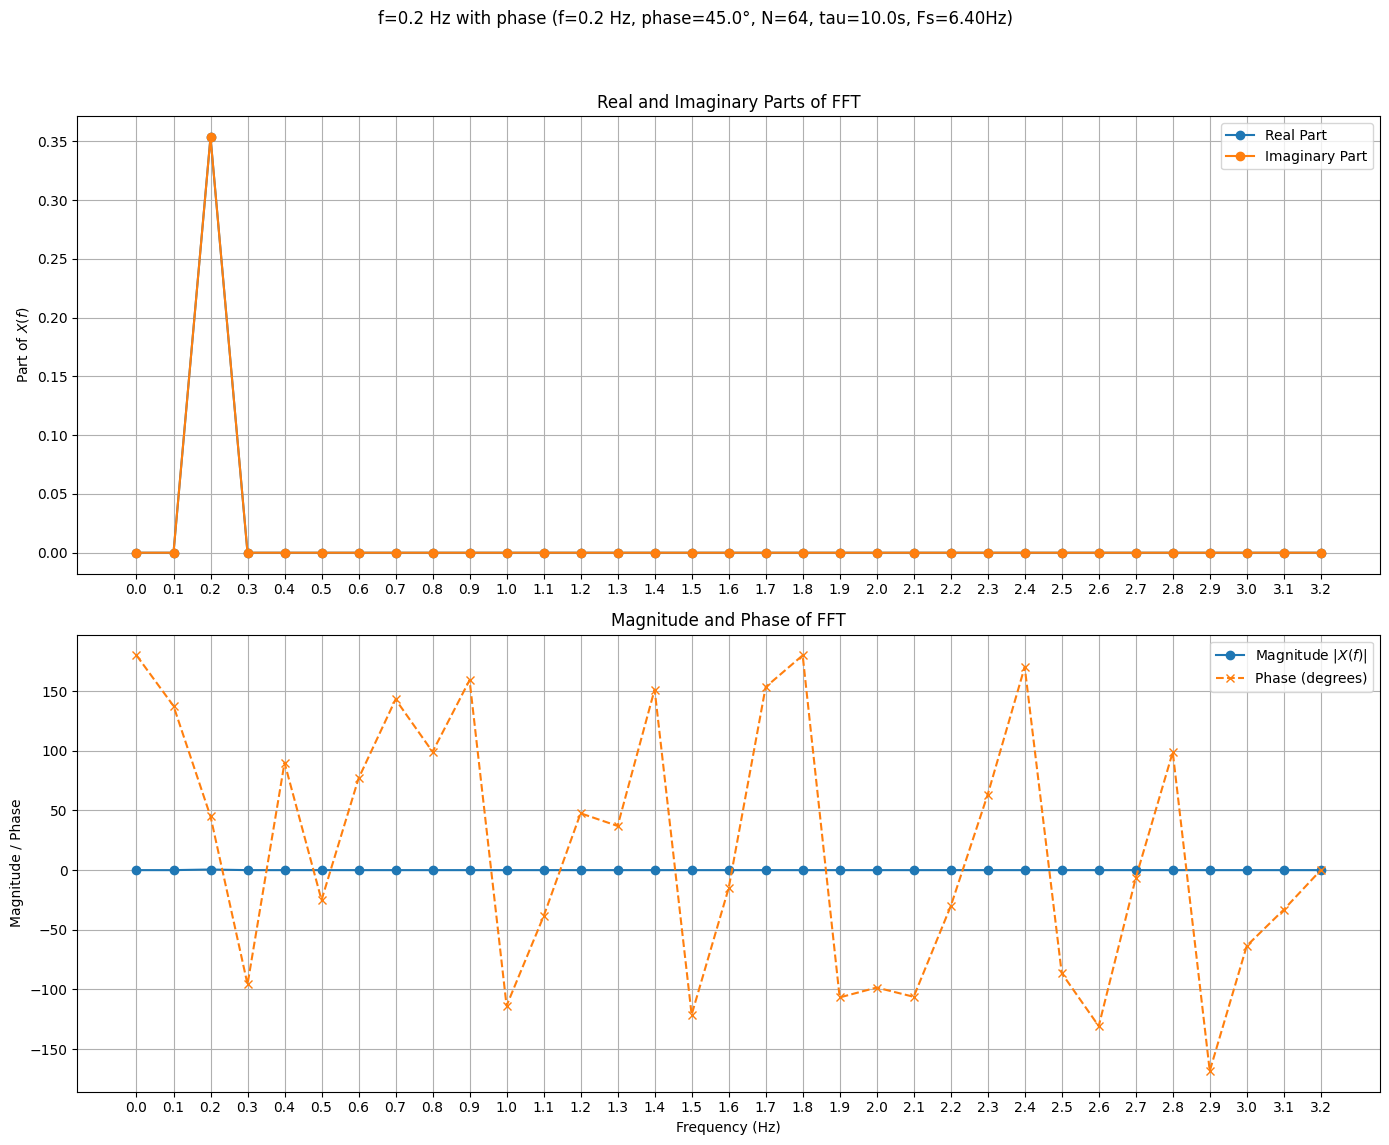

--- f=0.2 Hz with phase (f=0.2 Hz, phase=45.0°) ---
Peak Frequency Bin: 0.200 Hz
Magnitude at peak: 0.500
Phase at peak (degrees): 45.0




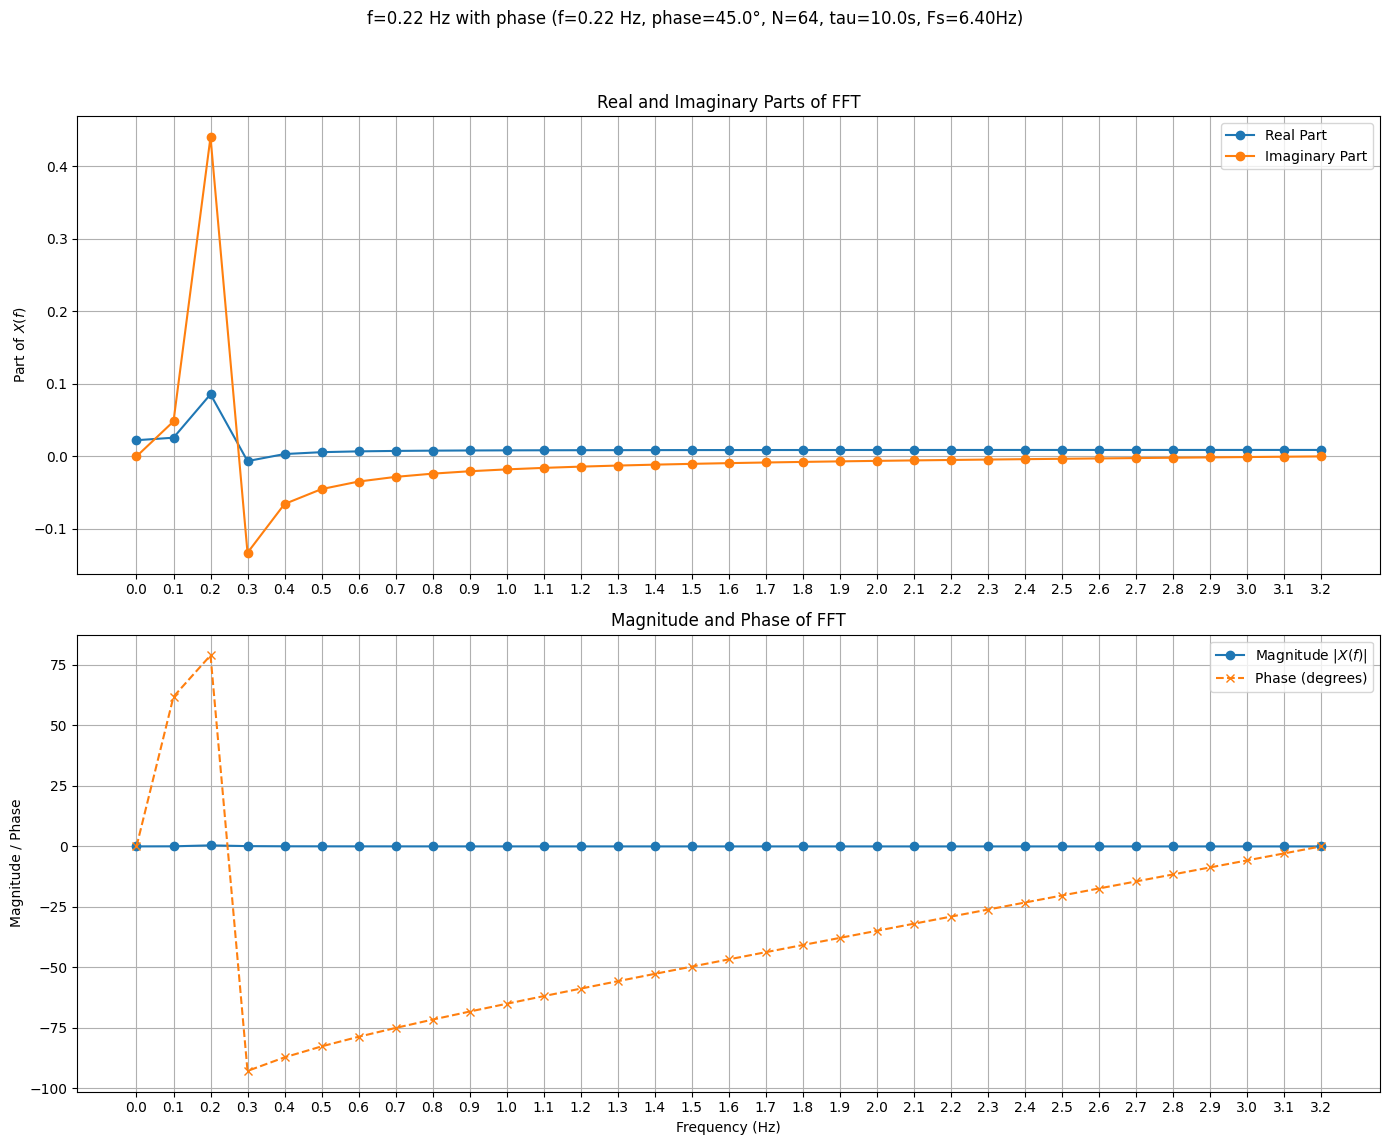

--- f=0.22 Hz with phase (f=0.22 Hz, phase=45.0°) ---
Peak Frequency Bin: 0.200 Hz
Magnitude at peak: 0.449
Phase at peak (degrees): 79.0




In [9]:
def Spectrum1(x, Fs):
    '''
    One-sided amplitude spectrum of x(t).
    '''
    N = len(x) # length of the signal
    frq = (float(Fs)/N)*np.arange(0, N/2+1) # one-sided frequency range
    X = fft(x)/N # fft computing and normalization
    X = X[0:N//2+1] # take just positive values

    # frq is array of actual frequencies
    # X is complex array of amplitudes
    return frq , X

def plot_fft_with_phase_scenario(N_val, tau_val, f_val, phase_val, scenario_description):
    '''
    Helper function to generate signal with phase, compute FFT, and plot results including phase.
    '''
    t = np.linspace(0, tau_val, N_val, endpoint=False)
    Fs_val = N_val / tau_val # Sampling rate
    # Introduce phase here: x(t) = cos(2*pi*f*t + phase)
    x_val = np.cos(2*np.pi*f_val*t + phase_val)

    frq, X_spectrum = Spectrum1(x_val, Fs_val)

    plt.figure(figsize=(14, 12))
    plt.suptitle(f'{scenario_description} (f={f_val} Hz, phase={np.degrees(phase_val):.1f}°, N={N_val}, tau={tau_val}s, Fs={Fs_val:.2f}Hz)')

    # Plot Real and Imaginary parts of X
    plt.subplot(2, 1, 1)
    plt.plot(frq, np.real(X_spectrum), 'o-', label='Real Part')
    plt.plot(frq, np.imag(X_spectrum), 'o-', label='Imaginary Part')
    plt.ylabel('Part of $X(f)$')
    plt.title('Real and Imaginary Parts of FFT')
    plt.grid(True)
    plt.xticks(np.arange(0, frq[-1] + 0.1, 0.1) if frq[-1] > 0.1 else None)
    plt.legend()

    # Plot Magnitude |X| and Argument (Phase) of X
    plt.subplot(2, 1, 2)
    plt.plot(frq, np.abs(X_spectrum), 'o-', label='Magnitude $|X(f)|$')
    plt.plot(frq, np.degrees(np.angle(X_spectrum)), 'x--', label='Phase (degrees)') # Plot phase in degrees
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude / Phase')
    plt.title('Magnitude and Phase of FFT')
    plt.grid(True)
    plt.xticks(np.arange(0, frq[-1] + 0.1, 0.1) if frq[-1] > 0.1 else None)
    plt.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print(f"--- {scenario_description} (f={f_val} Hz, phase={np.degrees(phase_val):.1f}°) ---")
    peak_freq_idx = np.argmax(np.abs(X_spectrum))
    print(f"Peak Frequency Bin: {frq[peak_freq_idx]:.3f} Hz")
    print(f"Magnitude at peak: {np.abs(X_spectrum[peak_freq_idx]):.3f}")
    print(f"Phase at peak (degrees): {np.degrees(np.angle(X_spectrum[peak_freq_idx])):.1f}")
    print("\n")


# --- Exercise 6: Investigation ---

N_val = 64
tau_val = 10.0
Fs_val = N_val / tau_val

# Choose a non-zero phase, e.g., pi/4 radians (45 degrees)
phase_example = np.pi / 4

print("Investigating the effect of non-zero phase in cosine waves.")

# Scenario 1: f=0.2 Hz with phase
plot_fft_with_phase_scenario(
    N_val=N_val, tau_val=tau_val, f_val=0.2, phase_val=phase_example,
    scenario_description='f=0.2 Hz with phase'
)

# Scenario 2: f=0.22 Hz with phase (showing spectral leakage with phase)
plot_fft_with_phase_scenario(
    N_val=N_val, tau_val=tau_val, f_val=0.22, phase_val=phase_example,
    scenario_description='f=0.22 Hz with phase'
)


# Explanation for demonstrator:
# Summary of Observations for Exercise 6:
# When a non-zero phase is introduced to the cosine wave, the FFT results change significantly, primarily affecting the imaginary part and the argument (phase) of the complex coefficients.

# For f=0.2 Hz (on-bin frequency) with non-zero phase:
# - Magnitude |X(f)|: The magnitude spectrum still shows a sharp peak at 0.2 Hz with an amplitude of 0.5, similar to the zero-phase case. The amplitude of a single frequency component is independent of its phase.
# - Real and Imaginary Parts: Unlike a zero-phase cosine (purely real FFT), both the real and imaginary parts of the FFT at 0.2 Hz become non-zero. The values depend on the input phase. Specifically, for cos(theta + phi), the FFT component will be (0.5 * e^(i*phi)) at positive frequency and (0.5 * e^(-i*phi)) at negative frequency. So, real and imaginary parts will reflect cos(phi) and sin(phi) components.
# - Phase (Argument) of X(f): The phase plot now shows a distinct non-zero value at 0.2 Hz, which corresponds to the `phase_example` (45 degrees in this case). This demonstrates that the FFT correctly captures the phase information of the original signal.

# For f=0.22 Hz (off-bin frequency) with non-zero phase:
# - Magnitude |X(f)|: Spectral leakage is still present, meaning the energy is spread across multiple frequency bins, and the peak magnitude is less than 0.5. The phase doesn't eliminate spectral leakage; it only changes how the energy is distributed across the real and imaginary parts within the leaked bins.
# - Real and Imaginary Parts: Both real and imaginary parts show distributed energy across multiple bins due to leakage. Their values are a combination of the leakage effect and the introduced phase.
# - Phase (Argument) of X(f): The phase plot appears much noisier and less well-defined, especially around the main frequency components. This is because the spectral leakage causes components from the true frequency to overlap with other bins, making the phase at any single bin a complex mix of contributions, not a pure reflection of the original signal's phase. The phase in leaked bins doesn't accurately represent the true signal's phase, but rather the phase of the composite signal in that bin due to the leakage.

## Exercise 7

[4] Write a function `TestData(N, Fs)` which creates $N$ points of data containing three cosine waves with amplitudes and frequencies $a_1 = 1.0, f_1 = 12.3, a_2 = 0.5, f_2 = 7.5, a_3 = 0.2, f_3 = 30.0$. Use this function to plot the FFT for N=512, 1024 and 2048 and explain the results.

 Recall: The time separation between points is $\Delta t = 1/F_s$. Read the section Summary above!

--- Exercise 7: FFT of three cosine waves ---


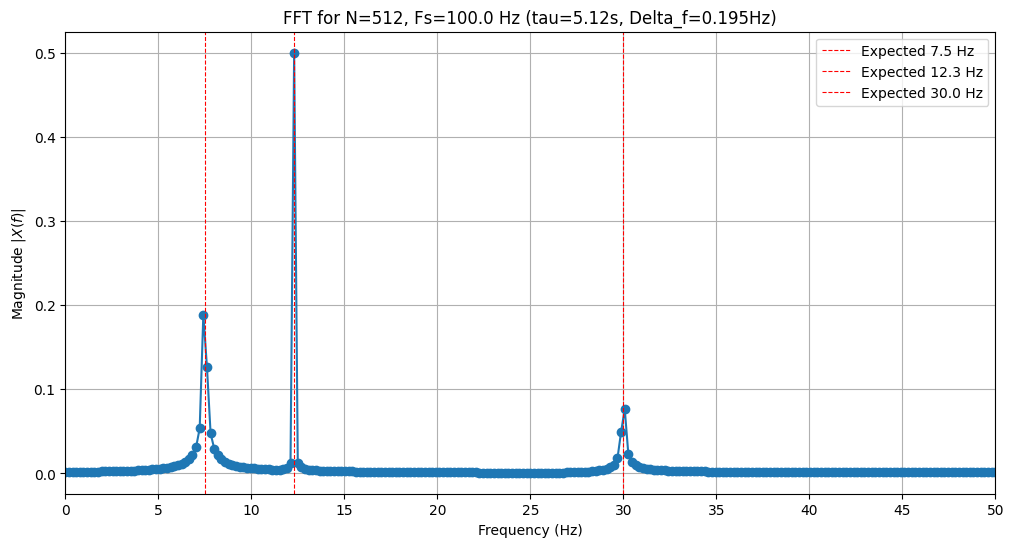

Results for N=512:
  tau = 5.12 s, Delta f = 0.195 Hz
  Peak at 12.305 Hz with magnitude 0.500
  Peak at 7.422 Hz with magnitude 0.189
  Peak at 7.617 Hz with magnitude 0.127




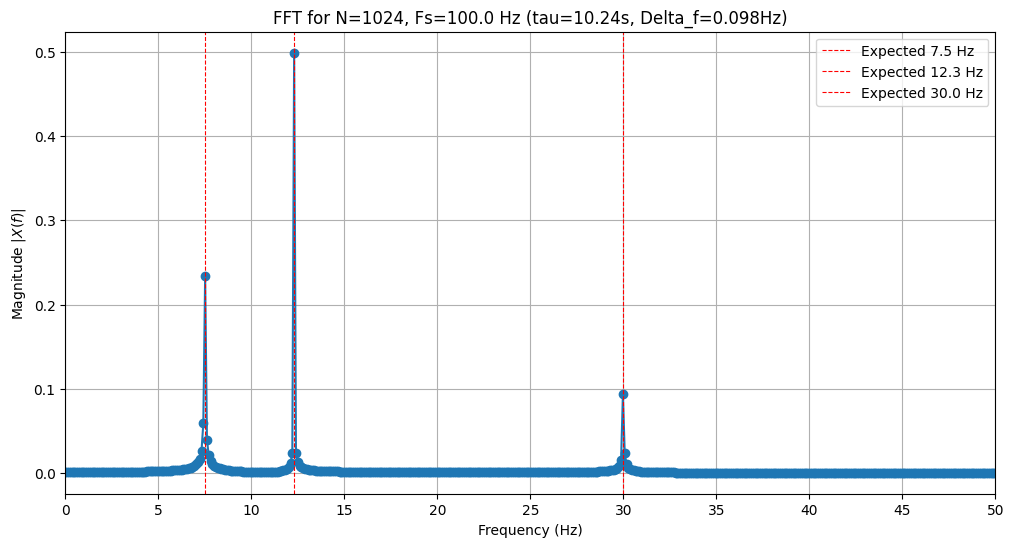

Results for N=1024:
  tau = 10.24 s, Delta f = 0.098 Hz
  Peak at 12.305 Hz with magnitude 0.499
  Peak at 7.520 Hz with magnitude 0.234
  Peak at 29.980 Hz with magnitude 0.094




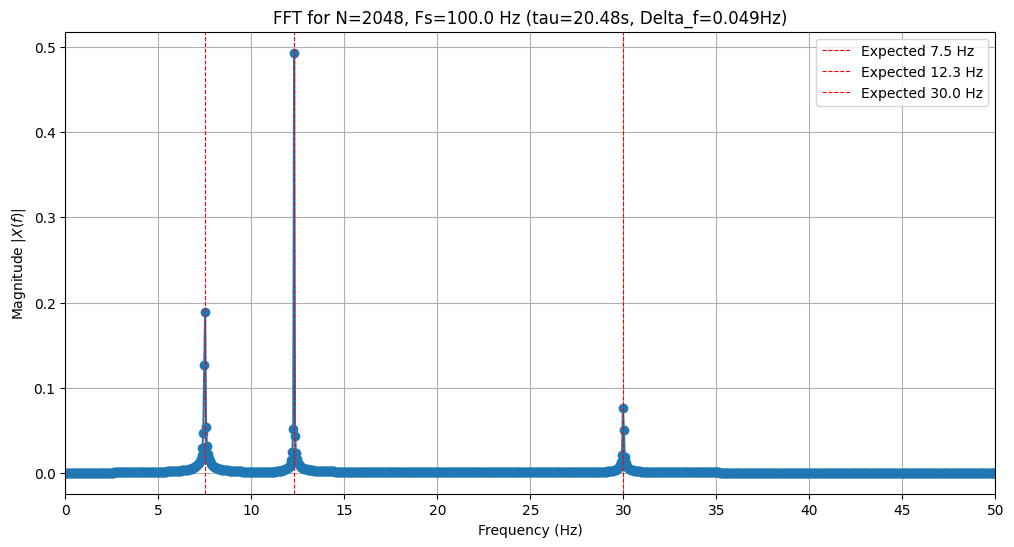

Results for N=2048:
  tau = 20.48 s, Delta f = 0.049 Hz
  Peak at 12.305 Hz with magnitude 0.493
  Peak at 7.520 Hz with magnitude 0.189
  Peak at 7.471 Hz with magnitude 0.126




In [10]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.fft import fft, ifft

def Spectrum1(x, Fs):
    '''
    One-sided amplitude spectrum of x(t).
    '''
    N = len(x) # length of the signal
    frq = (float(Fs)/N)*np.arange(0, N//2+1) # one-sided frequency range
    X = fft(x)/N # fft computing and normalization
    X = X[0:N//2+1] # take just positive values
    return frq , X

def TestData(N, Fs):
    '''
    Creates N points of data containing three cosine waves.
    Amplitudes and frequencies: a1=1.0, f1=12.3; a2=0.5, f2=7.5; a3=0.2, f3=30.0.
    '''
    tau = N / Fs # Total duration of the signal
    t = np.linspace(0, tau, N, endpoint=False)

    a1, f1 = 1.0, 12.3
    a2, f2 = 0.5, 7.5
    a3, f3 = 0.2, 30.0

    x = a1 * np.cos(2*np.pi*f1*t) + \
        a2 * np.cos(2*np.pi*f2*t) + \
        a3 * np.cos(2*np.pi*f3*t)

    return t, x, Fs

# Parameters for investigation
Ns = [512, 1024, 2048]
fixed_Fs = 100.0 # Hz, chosen to be > 2*max(f) = 2*30 = 60 Hz to avoid aliasing for all components.

print("--- Exercise 7: FFT of three cosine waves ---")

for N_val in Ns:
    t_data, x_data, Fs_data = TestData(N_val, fixed_Fs)
    tau_data = N_val / Fs_data
    delta_f = 1.0 / tau_data

    frq, X_spectrum = Spectrum1(x_data, Fs_data)

    plt.figure(figsize=(12, 6))
    plt.plot(frq, np.abs(X_spectrum), 'o-')
    plt.title(f'FFT for N={N_val}, Fs={Fs_data} Hz (tau={tau_data:.2f}s, Delta_f={delta_f:.3f}Hz)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude $|X(f)|$')
    plt.grid(True)
    # Highlight expected frequencies
    expected_freqs = [7.5, 12.3, 30.0]
    for ef in expected_freqs:
        plt.axvline(ef, color='r', linestyle='--', linewidth=0.8, label=f'Expected {ef} Hz')
    plt.xlim(0, Fs_data/2) # Limit x-axis to Nyquist frequency
    plt.xticks(np.arange(0, Fs_data/2 + 5, 5))
    plt.legend()
    plt.show()

    peak_indices = np.argsort(np.abs(X_spectrum))[::-1][:3] # Get indices of 3 largest peaks
    print(f"Results for N={N_val}:")
    print(f"  tau = {tau_data:.2f} s, Delta f = {delta_f:.3f} Hz")
    for idx in peak_indices:
        if np.abs(X_spectrum[idx]) > 0.01: # Only print significant peaks
            freq_at_peak = frq[idx]
            mag_at_peak = np.abs(X_spectrum[idx])
            print(f"  Peak at {freq_at_peak:.3f} Hz with magnitude {mag_at_peak:.3f}")
    print("\n")

# Explanation of Results:
# The `TestData` function generates a signal that is the sum of three cosine waves with amplitudes (1.0, 0.5, 0.2) and frequencies (12.3 Hz, 7.5 Hz, 30.0 Hz) respectively.
# The `Spectrum1` function calculates the one-sided amplitude spectrum, where the amplitude of a pure cosine wave A*cos(2*pi*f*t) appears as A/2 at frequency f.
# Therefore, the theoretical magnitudes of the peaks should be 1.0/2 = 0.5, 0.5/2 = 0.25, and 0.2/2 = 0.1 at 12.3 Hz, 7.5 Hz, and 30.0 Hz, respectively.

# We kept the sampling frequency (Fs) constant at 100 Hz. This ensures that the Nyquist frequency (Fs/2 = 50 Hz) is always well above our maximum signal frequency of 30 Hz, preventing aliasing.

# As we increase N (the number of sample points) from 512 to 1024 and then to 2048:
# 1. Total Observation Time (tau): Since Fs is fixed, increasing N directly increases the total observation time (tau = N/Fs). This changes from 5.12s to 10.24s to 20.48s.
# 2. Frequency Resolution (Delta f): The frequency resolution, Delta f = 1/tau, directly improves (decreases) as tau increases. This means the spacing between the discrete frequency bins in the FFT becomes finer (0.195 Hz -> 0.098 Hz -> 0.049 Hz).
# 3. Spectral Leakage: Because the original signal frequencies (7.5, 12.3, 30.0 Hz) are not exact integer multiples of the initial Delta f (0.195 Hz for N=512), spectral leakage occurs, causing the energy to spread across multiple bins. The peak magnitudes are slightly lower than their theoretical A/2 values, and the peaks appear broader.
# 4. Improved Peak Sharpness and Accuracy: As N increases, Delta f becomes smaller. This means the frequency bins get closer to the actual frequencies of the cosine waves. As a result, the spectral leakage is significantly reduced, making the FFT peaks appear much sharper and their magnitudes closer to the theoretical 0.5, 0.25, and 0.1 values. For N=2048, the frequency resolution is fine enough that the peaks are very close to the true frequencies and amplitudes.

# In summary, increasing the number of sample points (N) while keeping the sampling rate (Fs) fixed improves the frequency resolution of the FFT by increasing the observation time (tau). This leads to sharper peaks that more accurately represent the true frequencies and amplitudes of the underlying sinusoidal components, minimizing the effects of spectral leakage.